# Faithfulness and completeness of the IPE circuits: path search vs. tree search

Produces the comparison tables for the *tree extension* chapter: **faithfulness** and
**completeness** of the circuits returned by

* `PathMessagePatching` — the path search (paths are enumerated independently), and
* `TreeMessagePatching` — the tree extension (the same paths materialised as a suffix-sharing trie),

over a sweep of the admission threshold `min_contribution`, on **GPT-2 small / IOI**, against the
manually reverse-engineered circuit of Wang et al. (2023).

## Definitions

Both scores are the ones defined in *Interpretability in the Wild* (Wang et al., 2023,
[arXiv:2211.00593](https://arxiv.org/pdf/2211.00593), §3), evaluated by **knockout**: given a circuit
`C` (a set of graph elements) we run the model with **every element not in `C` mean-ablated over the
ABC distribution** and read off the IOI logit difference

$$ F(C) \;=\; \mathbb{E}\big[\,\mathrm{logit}(\text{IO}) - \mathrm{logit}(\text{S})\,\big]
   \quad\text{with } \bar{C} \text{ knocked out.} $$

* **Faithfulness** — `F(C) ≈ F(M)`: the circuit alone reproduces the full model's behaviour.
  Reported raw, plus normalised so that `1.0` = the full model and `0.0` = the empty circuit,
  $$\widehat{F}(C) = \frac{F(C) - F(\varnothing)}{F(M) - F(\varnothing)}.$$
* **Completeness** — for *every* subset `K ⊆ C`, `F(C\K) ≈ F(M\K)`: nothing outside the circuit
  compensates for the removal of a part of it. Following the paper we estimate the *incompleteness*
  $$ \mathrm{incompl}(C) = \mathbb{E}_{K}\ \frac{\big|F(C\setminus K) - F(M\setminus K)\big|}{F(M) - F(\varnothing)} $$
  over randomly sampled `K` (mean and max are both reported); `completeness = 1 − incompl`.

The MIB benchmark ([arXiv:2504.13151](https://arxiv.org/pdf/2504.13151)) turns the same knockout into
its area-under-the-curve summaries CPR and CMD. We deliberately stop at plain faithfulness /
completeness here; the per-threshold rows below are exactly the points those areas integrate over, so
CPR/CMD can be added later without recomputing anything.

## Design notes (worth knowing before reading the numbers)

**The ground-truth baseline keeps the MLPs.** Wang et al.'s circuit is a set of *attention heads*;
its MLPs are unspecified, not excluded. Ablating them because they are "not in `C`" deletes all 12 MLP
sublayers, which destroys the model by itself — all 144 attention heads with the MLPs ablated score
below the empty circuit — so every head set would score ~0 and the comparison would flatter the
searches for no reason. Both readings are reported (`ground truth` and `ground truth (MLPs ablated)`);
the first is the one to compare against.

**The evaluation is independent of the discovery signal.** The searches are driven by the IPE
contribution (counterfactual denoising, `logit_difference` metric, the `s2_io_flip` counterfactual).
The knockout above uses a *different* intervention — ABC mean-ablation — and a *different, larger*
prompt set. A circuit that merely memorised its own scoring rule would not score well here.

**Two granularities.** A circuit is read off the search output at two levels:

| granularity | element | what the knockout does |
|---|---|---|
| `node` | a component: attention head `a{l}.h{h}` or `m{l}` | replaces the output of every component outside `C`. This is literally Wang et al.'s knockout, and it is what the head-level ground truth is defined on. |
| `edge` | `(source → destination, stream)` with stream ∈ `q/k/v/mlp/resid` | each destination input is rebuilt from the *running* value of its allowed parents and the ablated value of the rest (the ACDC / MIB edge-patching semantics). |

Node granularity collapses a path set and a tree onto the same object whenever they touch the same
components, so it is the **edge** table that shows what the tree extension buys: the trie constrains
*which parent each admitted component may feed*, which the path set only records implicitly.

The stream of an edge is recoverable even in the non-positional search: `get_expansion_candidates`
emits a predecessor either for the query branch (`patch_query=True`) or for the key/value branch
(`patch_key=patch_value=True`), so a node's own patch flags say which of *its* inputs its children
feed.

**How the tree search scores candidates.** The tree runs with `joint_scoring=True`: a candidate `C`
under frontier leaf `L` is scored *in the context of the tree grown so far*,

$$ \mathrm{score}(C) \;=\; \mathbb{F}\big(T \text{ with } L \text{ emitting } f_L(m_C)\big) \;-\; \mathbb{F}\big(T \text{ with } L \text{ emitting } 0\big), $$

with every other branch of `T` frozen, `𝔽 = evaluate_tree` and `f_L` the node's difference operator.
`C`'s message therefore merges with the other subtrees' messages at every shared ancestor and at
`ln_final`, instead of travelling to the root alone as it does under the isolated rule
`evaluate_path([C, L, …, root])` that the path search uses.

Two things follow, both of which shape this notebook:

* **The baseline is "`L` contributes nothing", not "`L` ablated whole".** A childless node emits its
  *full* output (`get_tree_msg` → `forward(None)`), so attaching a child **narrows** an ablation
  rather than adding one — exactly so, since with all of `L`'s predecessors admitted
  `f_L(Σ m_c) = f_L(None)`. Measuring against the unattached tree would therefore make every score
  past depth 0 negative. With this baseline the score keeps the isolated rule's sign and scale, and
  reduces to `evaluate_path([C, root])` at depth 0, where the tree is empty.
* **The threshold sweep is no longer derivable from one run.** An isolated contribution depends only
  on its own chain, so it is threshold-independent and a single run at the lowest threshold
  reproduces every higher one exactly by pruning. A joint contribution is only valid for the tree
  that existed when it was taken, and that tree depends on the threshold.

So the sweep is **asymmetric**, and deliberately:

| | runs | how the sweep is obtained |
|---|---|---|
| path search | one, at `base_min_contribution` | prune: keep a complete path iff `min |contribution|` over its nodes `≥ t` |
| tree search (`joint_scoring=True`) | one **per threshold** | each run is already the circuit at its own `t` |
| tree search (`joint_scoring=False`) | one, at `base_min_contribution` | prune: drop every node with `|contribution| < t`, and its subtree |

The extra cost is smaller than it looks: the lowest threshold dominates and the higher ones get
progressively cheaper, so the whole tree sweep costs roughly twice a single base run. Set
`CFG.tree_joint_scoring = False` to recover the single-run behaviour and the isolated scoring the
path search uses.

Every run is cached in `experiments/detected_paths/` as plain, model-free JSON, keyed by threshold
and scoring mode, so all the tables below can be recomputed from cache without a GPU.

In [26]:
import functools
import itertools
import json
import math
import os
import pickle
import random
import sys
import time
from collections import defaultdict
from dataclasses import asdict, dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

EXPERIMENTS_DIR = os.getcwd()                      # this notebook lives in experiments/
REPO_ROOT = os.path.dirname(EXPERIMENTS_DIR)
for p in (os.path.join(REPO_ROOT, "src"), REPO_ROOT, EXPERIMENTS_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)                      # `ipe` is used from src/, not pip-installed

SEARCH_CACHE_DIR = os.path.join(EXPERIMENTS_DIR, "detected_paths")
OUT_DIR = os.path.join(EXPERIMENTS_DIR, "faithfulness_completeness")
os.makedirs(SEARCH_CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)                      # nothing here needs gradients
print(f"device: {DEVICE}   outputs -> {OUT_DIR}")

device: cuda   outputs -> /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness


## 1. Configuration

`base_min_contribution` is the only setting that costs real time: it is the threshold the searches
actually run at, and the sweep can only reach thresholds **above** it. Everything else is cheap.

Set `QUICK = True` to exercise the whole pipeline (search included) in a couple of minutes at a
coarse threshold; the shape of the curves survives, they just start much further right.

In [27]:
@dataclass
class Config:
    # --- model / task -------------------------------------------------------
    model_name: str = "gpt2-small"
    target_length: int = 15            # tokenised prompt length the batch is bucketed to

    # --- IPE search ---------------------------------------------------------
    search_batch: int = 5              # prompts the search itself scores on
    search_metric: str = "logit_difference"
    base_min_contribution: float = 0.05
    include_negative: bool = True      # admit by |contribution|
    positional: bool = False           # non-positional, as in MIB/run_search.py for IOI
    batch_heads: bool = False          # per-head expansion for BOTH searches (parity)
    tree_joint_scoring: bool = True    # score tree candidates in the context of the tree so far

    # --- threshold sweep ----------------------------------------------------
    n_thresholds: int = 8
    max_threshold: float = 2.0

    # --- knockout evaluation ------------------------------------------------
    eval_size: int = 64                # IOI prompts the faithfulness metric averages over
    eval_minibatch: int = 16
    ablation: str = "mean"             # "mean" = ABC mean-ablation (Wang et al.) | "resample"

    # --- completeness -------------------------------------------------------
    n_completeness_samples: int = 20
    completeness_max_frac: float = 0.5  # |K| drawn uniformly from 1 .. frac * |C|
    seed: int = 0

CFG = Config()

QUICK = False
if QUICK:
    CFG.base_min_contribution = 0.5
    CFG.n_thresholds = 4
    CFG.max_threshold = 2.0
    CFG.eval_size, CFG.eval_minibatch = 16, 16
    CFG.n_completeness_samples = 5

GRANULARITIES = ("node", "edge")
INCLUDE_RANDOM_BASELINE = True         # random circuit of matched size, as a sanity floor

random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)

def sweep_thresholds(cfg: Config) -> list[float]:
    """Log-spaced grid from the threshold the search ran at up to `max_threshold`."""
    lo, hi = cfg.base_min_contribution, cfg.max_threshold
    if hi <= lo:
        return [lo]
    return [float(t) for t in np.geomspace(lo, hi, cfg.n_thresholds)]

THRESHOLDS = sweep_thresholds(CFG)
print("thresholds:", [f"{t:.4g}" for t in THRESHOLDS])

def search_cache_file(cfg: Config, which: str, threshold: float = None) -> str:
    """Cache path for one search run.

    The tree's file is keyed by threshold *and* scoring mode: under joint scoring a run at one
    threshold says nothing about another, so each needs its own search (see section 4)."""
    t = cfg.base_min_contribution if threshold is None else threshold
    scoring = "joint" if (which == "treesearch" and cfg.tree_joint_scoring) else "isolated"
    stem = (f"{which}_{scoring}_{cfg.model_name}_ioi_{cfg.search_metric}_th{t:g}"
            f"_bs{cfg.search_batch}_len{cfg.target_length}_pos{cfg.positional}"
            f"_heads{not cfg.batch_heads}.json")
    return os.path.join(SEARCH_CACHE_DIR, stem)

print(os.path.basename(search_cache_file(CFG, "pathsearch")))
for t in THRESHOLDS[:2]:
    print(os.path.basename(search_cache_file(CFG, "treesearch", t)))
print(f"tree scoring: {'joint (in context)' if CFG.tree_joint_scoring else 'isolated (per branch)'}"
      f"  ->  {len(THRESHOLDS) if CFG.tree_joint_scoring else 1} tree search(es)")

thresholds: ['0.05', '0.08469', '0.1435', '0.243', '0.4116', '0.6971', '1.181', '2']
pathsearch_isolated_gpt2-small_ioi_logit_difference_th0.05_bs5_len15_posFalse_headsTrue.json
treesearch_joint_gpt2-small_ioi_logit_difference_th0.05_bs5_len15_posFalse_headsTrue.json
treesearch_joint_gpt2-small_ioi_logit_difference_th0.0846907_bs5_len15_posFalse_headsTrue.json
tree scoring: joint (in context)  ->  8 tree search(es)


## 2. Data

Two disjoint slices of `mib-bench/ioi`, both bucketed to `target_length` tokens:

* the **search batch** (small) with its `s2_io_flip` counterfactual — fed to the IPE searches with the
  clean/counterfactual inversion used by `experiments/MIB/run_search.py` and `tree_vs_path.py`
  (clean and counterfactual prompts solve the same task with different names, so the roles swap and
  the counterfactual run becomes the base run);
* the **evaluation set** (larger, drawn from later samples) with its `abc_counterfactual` — the ABC
  distribution Wang et al. mean-ablate over. IO and S come from `metadata`, so the logit difference is
  the standard IOI one.

In [28]:
from transformer_lens import HookedTransformer


def load_model(cfg: Config) -> HookedTransformer:
    """GPT-2 with the hook points the edge-level knockout needs.

    `center_unembed` shifts every logit by a per-position constant, which cancels in a logit
    *difference*, so it does not touch the metric."""
    model = HookedTransformer.from_pretrained(
        cfg.model_name, device=DEVICE, torch_dtype=torch.float32, center_unembed=True,
    )
    model.eval()
    model.cfg.use_attn_result = True       # per-head outputs at blocks.L.attn.hook_result
    model.cfg.use_split_qkv_input = True   # per-head q/k/v inputs, so edges can target one stream
    model.cfg.use_hook_mlp_in = True       # writable MLP input
    return model


MODEL = load_model(CFG)
N_LAYERS, N_HEADS = MODEL.cfg.n_layers, MODEL.cfg.n_heads
print(f"{CFG.model_name}: {N_LAYERS} layers x {N_HEADS} heads")

Loaded pretrained model gpt2-small into HookedTransformer
gpt2-small: 12 layers x 12 heads


In [29]:
def _single_token(model, text: str) -> bool:
    return len(model.to_str_tokens(text, prepend_bos=False)) == 1


def load_ioi_samples(model, cfg: Config, n: int, skip: int = 0, split: str = "train") -> list[dict]:
    """`n` IOI samples of exactly `cfg.target_length` tokens whose IO / S are single tokens and
    whose ABC counterfactual tokenises to the same length (needed to mean-ablate position-wise)."""
    from datasets import load_dataset

    ds = load_dataset("mib-bench/ioi", split=split)
    out, seen = [], 0
    for sample in ds:
        if model.to_tokens(sample["prompt"], prepend_bos=True).shape[1] != cfg.target_length:
            continue
        io, subj = sample["metadata"]["indirect_object"], sample["metadata"]["subject"]
        if not (_single_token(model, f" {io}") and _single_token(model, f" {subj}")):
            continue
        abc = sample["abc_counterfactual"]["prompt"]
        if model.to_tokens(abc, prepend_bos=True).shape[1] != cfg.target_length:
            continue
        seen += 1
        if seen <= skip:
            continue
        out.append(sample)
        if len(out) >= n:
            break
    if len(out) < n:
        raise RuntimeError(f"only {len(out)}/{n} usable IOI samples of length {cfg.target_length}")
    return out


@dataclass
class SearchBatch:
    prompts: list[str]
    answers: list[str]
    cf_prompts: list[str]
    cf_answers: list[str]


@dataclass
class EvalSet:
    tokens: torch.Tensor        # [N, pos]  clean IOI prompts
    abc_tokens: torch.Tensor    # [N, pos]  ABC counterfactuals (the ablation distribution)
    io: torch.Tensor            # [N]       indirect-object token ids
    s: torch.Tensor             # [N]       subject token ids


def build_search_batch(model, cfg: Config, samples: list[dict]) -> SearchBatch:
    cf_key = "s2_io_flip_counterfactual"
    prompts, answers, cf_prompts, cf_answers = [], [], [], []
    for s in samples:
        prompts.append(s["prompt"])
        answers.append(" " + s["metadata"]["indirect_object"])
        cf_prompts.append(s[cf_key]["prompt"])
        cf_answers.append(" " + s[cf_key]["choices"][s[cf_key]["answerKey"]])
    return SearchBatch(prompts, answers, cf_prompts, cf_answers)


def build_eval_set(model, samples: list[dict]) -> EvalSet:
    prompts = [s["prompt"] for s in samples]
    abc = [s["abc_counterfactual"]["prompt"] for s in samples]
    io = [model.to_single_token(" " + s["metadata"]["indirect_object"]) for s in samples]
    subj = [model.to_single_token(" " + s["metadata"]["subject"]) for s in samples]
    return EvalSet(
        tokens=model.to_tokens(prompts, prepend_bos=True),
        abc_tokens=model.to_tokens(abc, prepend_bos=True),
        io=torch.tensor(io, device=DEVICE),
        s=torch.tensor(subj, device=DEVICE),
    )


search_samples = load_ioi_samples(MODEL, CFG, CFG.search_batch, skip=0)
eval_samples = load_ioi_samples(MODEL, CFG, CFG.eval_size, skip=CFG.search_batch)

SEARCH = build_search_batch(MODEL, CFG, search_samples)
EVAL = build_eval_set(MODEL, eval_samples)

print(f"search batch: {len(SEARCH.prompts)} prompts")
print(f"  clean  {SEARCH.prompts[0]!r} -> {SEARCH.answers[0]!r}")
print(f"  cfact  {SEARCH.cf_prompts[0]!r} -> {SEARCH.cf_answers[0]!r}")
print(f"eval set: {EVAL.tokens.shape[0]} prompts of {EVAL.tokens.shape[1]} tokens")
print(f"  clean  {eval_samples[0]['prompt']!r}")
print(f"  abc    {eval_samples[0]['abc_counterfactual']['prompt']!r}")
print(f"  IO/S   {MODEL.to_string(EVAL.io[:1])!r} / {MODEL.to_string(EVAL.s[:1])!r}")

search batch: 5 prompts
  clean  'After Bob and John went to the depot, Bob gave a lamp to' -> ' John'
  cfact  'After Bob and John went to the depot, John gave a lamp to' -> ' Bob'
eval set: 64 prompts of 15 tokens
  clean  'After Rod and Kevin went to the taxi, Rod gave a tie to'
  abc    'After Rod and Kevin went to the taxi, Christian gave a tie to'
  IO/S   ' Kevin' / ' Rod'


## 3. Ground truth

The manually reverse-engineered IOI circuit (Wang et al., 2023): 26 attention heads in 7 classes,
imported from `experiments/tree_vs_path.py` so the two scripts cannot drift apart. IOI has no
canonical MLP set, so MLPs are reported descriptively and never scored.

In [30]:
from tree_vs_path import IOI_CIRCUIT

GT_HEADS = {(l, h) for heads in IOI_CIRCUIT.values() for l, h in heads}
GT_NODES = {("attn", l, h) for l, h in GT_HEADS}
print(f"{len(GT_HEADS)} ground-truth heads in {len(IOI_CIRCUIT)} classes")
for group, heads in IOI_CIRCUIT.items():
    print(f"  {group:20s} {sorted(heads)}")

26 ground-truth heads in 7 classes
  Name Mover           [(9, 6), (9, 9), (10, 0)]
  Negative Name Mover  [(10, 7), (11, 10)]
  Backup Name Mover    [(9, 0), (9, 7), (10, 1), (10, 2), (10, 6), (10, 10), (11, 2), (11, 9)]
  S-Inhibition         [(7, 3), (7, 9), (8, 6), (8, 10)]
  Induction            [(5, 5), (5, 8), (5, 9), (6, 9)]
  Duplicate Token      [(0, 1), (0, 10), (3, 0)]
  Previous Token       [(2, 2), (4, 11)]


## 4. Running the two searches (cached)

Both searches share one `ExperimentManager` — same batch, same metric, same patching, same per-head
expansion granularity — so the only differences are path enumeration vs. trie construction and the
scoring rule. Each search gets its own `clone_root`, because both mutate `root.children` in place.

The path search runs **once**, at `base_min_contribution`; the tree search runs **once per threshold**
while `tree_joint_scoring` is on, for the reason given in the design note at the top. Results are
written to `experiments/detected_paths/*.json` as plain dicts (no model, no caches, no tensors),
carrying every node's `contribution`.

> **Cost.** This is the only expensive cell. At `min_contribution = 0.05` on GPT-2 small / IOI expect
> tens of minutes on a GPU for the path search, and roughly twice that for the whole tree sweep — the
> lowest threshold dominates it and the higher ones are progressively cheaper. Joint scoring itself is
> essentially free: it re-propagates only the `L → root` chain, so it costs `O(depth)` per candidate,
> the same order as the isolated rule. Every run is skipped when its cache file exists.

In [ ]:
from ipe.nodes import ATTN_Node, EMBED_Node, FINAL_Node, MLP_Node, Node
from ipe.experiment import ExperimentManager
from ipe.graph_search import PathMessagePatching, TreeMessagePatching, setup_tree_debug_log
from tree_vs_path import clone_root


def quiet_tree_logging() -> None:
    """The tree search emits one loguru record per scored candidate, and loguru's default sink is
    stderr — inside a notebook that is hundreds of thousands of lines. Drop the default sink and
    keep only the per-depth summaries, in a file."""
    from loguru import logger
    logger.remove()
    setup_tree_debug_log(os.path.join(OUT_DIR, "tree_search_debug.log"), level="INFO")


def node_to_dict(n: Node) -> dict:
    """Model-free description of one search node, keeping its branch contribution."""
    d = {"contribution": getattr(n, "contribution", None)}
    if isinstance(n, FINAL_Node):
        d["type"] = "final"
    elif isinstance(n, EMBED_Node):
        d["type"] = "embed"
    elif isinstance(n, MLP_Node):
        d.update(type="mlp", layer=n.layer)
    elif isinstance(n, ATTN_Node):
        d.update(type="attn", layer=n.layer, head=n.head,
                 q=bool(n.patch_query), k=bool(n.patch_key), v=bool(n.patch_value))
    else:
        raise TypeError(f"unknown node type: {type(n)}")
    if d["contribution"] is not None:
        d["contribution"] = float(d["contribution"])
    return d


def paths_to_json(paths: list[tuple[float, list[Node]]]) -> list[dict]:
    """`[(score, [EMBED, ..., FINAL]), ...]` -> serialisable records."""
    return [{"contribution": float(score), "nodes": [node_to_dict(n) for n in path]}
            for score, path in paths]


def tree_to_json(node: Node) -> dict:
    return {"node": node_to_dict(node), "children": [tree_to_json(c) for c in node.children]}


def build_experiment(cfg: Config) -> ExperimentManager:
    """The activation caches, the metric (with its computed baseline) and the root node that every
    search shares. Each search then gets its own `clone_root`, since they mutate `children` in place.

    The IOI inversion is the one `experiments/MIB/run_search.py` uses: clean and counterfactual
    prompts solve the same task with different names, so the roles are swapped and the counterfactual
    run becomes the base run."""
    return ExperimentManager(
        model=MODEL,
        prompts=SEARCH.cf_prompts,
        targets=SEARCH.cf_answers,
        cf_prompts=SEARCH.prompts,
        cf_targets=SEARCH.answers,
        algorithm="PathMessagePatching",
        search_strategy="Threshold",
        algorithm_params={"min_contribution": cfg.base_min_contribution,
                          "include_negative": cfg.include_negative},
        metric=cfg.search_metric,
        positional_search=cfg.positional,
        patch_type="counterfactual",
        patch_clean_into_cf=True,
    )


def run_path_search(cfg: Config, get_experiment, force: bool = False) -> dict:
    """One run at `base_min_contribution`; every higher threshold is derived from it by pruning."""
    out = search_cache_file(cfg, "pathsearch")
    if os.path.exists(out) and not force:
        print(f"cache hit: {os.path.basename(out)}")
        with open(out) as f:
            return json.load(f)

    experiment = get_experiment()
    t0 = time.time()
    paths = PathMessagePatching(
        MODEL, experiment.metric, clone_root(experiment.root),
        min_contribution=cfg.base_min_contribution,
        include_negative=cfg.include_negative,
        batch_heads=cfg.batch_heads,
    )
    seconds = time.time() - t0
    record = {"method": "path", "scoring": "isolated", "threshold": cfg.base_min_contribution,
              "config": asdict(cfg), "seconds": seconds, "paths": paths_to_json(paths)}
    with open(out, "w") as f:
        json.dump(record, f)
    print(f"path search @ {cfg.base_min_contribution:g}: {len(paths)} complete paths in {seconds:.0f}s")
    return record


def run_tree_search(cfg: Config, get_experiment, threshold: float, force: bool = False) -> dict:
    """One tree search at `threshold`, with the scoring rule `cfg.tree_joint_scoring` selects."""
    out = search_cache_file(cfg, "treesearch", threshold)
    if os.path.exists(out) and not force:
        print(f"cache hit: {os.path.basename(out)}")
        with open(out) as f:
            return json.load(f)

    experiment = get_experiment()
    quiet_tree_logging()
    t0 = time.time()
    root = TreeMessagePatching(
        MODEL, experiment.metric, clone_root(experiment.root),
        min_contribution=threshold,
        include_negative=cfg.include_negative,
        joint_scoring=cfg.tree_joint_scoring,
    )
    seconds = time.time() - t0
    record = {"method": "tree",
              "scoring": "joint" if cfg.tree_joint_scoring else "isolated",
              "threshold": threshold, "config": asdict(cfg), "seconds": seconds,
              "tree": tree_to_json(root)}
    with open(out, "w") as f:
        json.dump(record, f)
    print(f"tree search @ {threshold:g} ({record['scoring']}): {seconds:.0f}s")
    return record


def run_searches(cfg: Config, thresholds: list[float], force: bool = False) -> tuple[dict, dict]:
    """Both searches, cached. The path search runs once and is pruned across the sweep; the tree
    search runs once per threshold under joint scoring, once in total under isolated scoring."""
    experiment = None

    def get_experiment():
        # Built lazily and once: it costs two forward passes plus the metric baseline, and is
        # unnecessary when every run is a cache hit.
        nonlocal experiment
        if experiment is None:
            experiment = build_experiment(cfg)
        return experiment

    path_record = run_path_search(cfg, get_experiment, force)
    if cfg.tree_joint_scoring:
        tree_records = {t: run_tree_search(cfg, get_experiment, t, force) for t in thresholds}
    else:
        shared = run_tree_search(cfg, get_experiment, cfg.base_min_contribution, force)
        tree_records = {t: shared for t in thresholds}
    return path_record, tree_records


PATH_REC, TREE_RECS = run_searches(CFG, THRESHOLDS)

tree_runs = {id(r): r for r in TREE_RECS.values()}      # distinct runs, not distinct thresholds
print(f"\npath search: {len(PATH_REC['paths'])} complete paths in {PATH_REC['seconds']:.0f}s")
print(f"tree search: {len(tree_runs)} run(s) totalling {sum(r['seconds'] for r in tree_runs.values()):.0f}s, "
      f"scoring={'joint' if CFG.tree_joint_scoring else 'isolated'}")

## 5. From a search result to a circuit, at any threshold

A circuit is a set of **components** plus a set of **edges**, in the vocabulary the knockout below
speaks:

* component: `("attn", layer, head)`, `("mlp", layer)`, and the two boundary nodes `("input",)`
  (embeddings + positional embeddings) and `("logits",)`;
* edge: `(source, destination, stream)` with `stream ∈ {q, k, v, mlp, resid}` — which *input* of the
  destination the source feeds. It is read off the **destination's** own patch flags, because
  `get_expansion_candidates` generates a predecessor either for the query branch or for the key/value
  branch of the node it expands.

`path_circuit` and `tree_circuit` both take a threshold and prune to it. For the path search — and
for the tree under isolated scoring — that pruning *reproduces* the run at `t` exactly. For the tree
under joint scoring the record already is the run at `t`, so the prune is a no-op and simply passes
the circuit through.

In [ ]:
STREAMS = ("q", "k", "v", "mlp", "resid")
INPUT, LOGITS = ("input",), ("logits",)


def component_of(nd: dict) -> tuple:
    t = nd["type"]
    if t == "attn":
        return ("attn", nd["layer"], nd["head"])
    if t == "mlp":
        return ("mlp", nd["layer"])
    if t == "embed":
        return INPUT
    if t == "final":
        return LOGITS
    raise ValueError(t)


def streams_into(nd: dict) -> tuple[str, ...]:
    """Which input stream(s) of `nd` its children feed."""
    t = nd["type"]
    if t == "mlp":
        return ("mlp",)
    if t == "final":
        return ("resid",)
    if t == "attn":
        s = tuple(k for k in ("q", "k", "v") if nd.get(k))
        return s or ("q", "k", "v")     # a node with no flag set would be ambiguous; be inclusive
    raise ValueError(f"{t} cannot be the destination of an edge")


def component_label(c: tuple) -> str:
    if c == INPUT:
        return "input"
    if c == LOGITS:
        return "logits"
    return f"a{c[1]}.h{c[2]}" if c[0] == "attn" else f"m{c[1]}"


@dataclass
class Circuit:
    name: str
    nodes: set                      # components, boundary nodes included
    edges: set                      # (src, dst, stream)
    threshold: float = float("nan")
    n_paths: int = 0                # complete paths (path search) / root->leaf branches (tree)
    scope: str = "all"              # "all" | "attention"; see `scope_circuit` in section 6

    @property
    def components(self) -> set:
        """Circuit nodes that the knockout can actually ablate (no boundary nodes)."""
        return {n for n in self.nodes if n not in (INPUT, LOGITS)}

    @property
    def heads(self) -> set:
        return {(l, h) for kind, l, h in (n for n in self.nodes if n[0] == "attn")}

    @property
    def mlps(self) -> set:
        return {n[1] for n in self.nodes if n[0] == "mlp"}


def _chain_to_circuit(chain: list[dict], nodes: set, edges: set) -> None:
    """Add one [leaf, ..., root] chain of node dicts to `nodes` / `edges`."""
    for child, parent in zip(chain[:-1], chain[1:]):
        c, p = component_of(child), component_of(parent)
        nodes.add(c)
        nodes.add(p)
        for stream in streams_into(parent):
            edges.add((c, p, stream))


def path_circuit(rec: dict, t: float) -> Circuit:
    """Complete paths whose every node clears |contribution| >= t (the root carries none)."""
    nodes, edges, kept = set(), set(), 0
    for path in rec["paths"]:
        chain = path["nodes"]
        scores = [abs(n["contribution"]) for n in chain if n["contribution"] is not None]
        if scores and min(scores) < t:
            continue
        kept += 1
        _chain_to_circuit(chain, nodes, edges)
    return Circuit(name="path", nodes=nodes, edges=edges, threshold=t, n_paths=kept)


def tree_circuit(rec: dict, t: float) -> Circuit:
    """The tree with every node below the threshold — and its subtree — pruned away.

    A surviving node whose children were all pruned simply becomes a leaf, which is what the search
    at threshold `t` would itself have produced when none of its candidates cleared the bar."""
    nodes, edges, branches = set(), set(), 0

    def walk(entry: dict, chain: list[dict]) -> None:
        nonlocal branches
        nd = entry["node"]
        chain = [nd] + chain                      # chain is [this, parent, ..., root]
        nodes.add(component_of(nd))
        if len(chain) > 1:
            _chain_to_circuit(chain[:2], nodes, edges)
        kept_children = [c for c in entry["children"]
                         if c["node"]["contribution"] is None
                         or abs(c["node"]["contribution"]) >= t]
        if not kept_children:
            branches += 1
            return
        for child in kept_children:
            walk(child, chain)

    walk(rec["tree"], [])
    return Circuit(name="tree", nodes=nodes, edges=edges, threshold=t, n_paths=branches)


PATH_CIRCUITS = {t: path_circuit(PATH_REC, t) for t in THRESHOLDS}
# Under joint scoring TREE_RECS[t] is already the run at t, so the prune is a no-op; under isolated
# scoring it is the one base run and the prune is what reproduces the run at t.
TREE_CIRCUITS = {t: tree_circuit(TREE_RECS[t], t) for t in THRESHOLDS}

for t in THRESHOLDS:
    p, tr = PATH_CIRCUITS[t], TREE_CIRCUITS[t]
    print(f"t={t:7.4g}   path: {len(p.components):3d} comps {len(p.edges):5d} edges "
          f"{p.n_paths:6d} paths   |   tree: {len(tr.components):3d} comps {len(tr.edges):5d} edges "
          f"{tr.n_paths:6d} branches")

## 6. The knockout harness

The computational graph the knockout works on: `input` (embeddings + positional embeddings), every
attention head, every MLP, and `logits`. Attention head `(l, h)` reads from everything before layer
`l`; `m{l}` also reads the heads of its own layer; `logits` reads everything.

Two ways of removing what is outside the circuit, sharing one set of ablation activations:

* **node** — the output of every component outside `C` is replaced by its ablated value. Everything
  downstream recomputes on its own.
* **edge** — each destination input is rebuilt as
  `Σ_{u: (u→v) ∈ C} cur[u] + Σ_{u: (u→v) ∉ C} abl[u]` (+ the layer biases, which are never part of the
  graph). Two algebraically identical forms of that are used, whichever needs fewer tensor ops:
  `abl_base_v + Σ_present δ[u]` for a sparse circuit and `running_base_v − Σ_absent δ[u]` for a dense
  one, with `δ[u] = cur[u] − abl[u]`. Both are exact, so an all-edges circuit reproduces the clean
  model bit for bit — which is one of the sanity checks below.

Ablated values come from the **ABC counterfactual** run, averaged over the evaluation set
(`ablation="mean"`, Wang et al.) or taken per example (`ablation="resample"`).

In [ ]:
def all_components() -> list[tuple]:
    """Every ablatable component, in computation order."""
    comps = []
    for l in range(N_LAYERS):
        comps += [("attn", l, h) for h in range(N_HEADS)]
        comps.append(("mlp", l))
    return comps


ALL_COMPONENTS = all_components()


def upstream_of(dest: tuple) -> list[tuple]:
    """Components (plus `input`) whose output reaches `dest`'s input, in computation order."""
    if dest == LOGITS:
        upto_attn = upto_mlp = N_LAYERS
    elif dest[0] == "attn":
        upto_attn = upto_mlp = dest[1]
    elif dest[0] == "mlp":
        upto_attn, upto_mlp = dest[1] + 1, dest[1]   # an MLP also reads its own layer's heads
    else:
        raise ValueError(f"{dest} is not a destination")
    ups = [INPUT]
    for l in range(N_LAYERS):
        if l < upto_attn:
            ups += [("attn", l, h) for h in range(N_HEADS)]
        if l < upto_mlp:
            ups.append(("mlp", l))
    return ups


def streams_of_dest(dest: tuple) -> tuple[str, ...]:
    if dest == LOGITS:
        return ("resid",)
    return ("q", "k", "v") if dest[0] == "attn" else ("mlp",)


def fully_connected_edges(nodes: set) -> set:
    """Every edge the model's topology allows among `nodes` (boundary nodes always included)."""
    keep = set(nodes) | {INPUT, LOGITS}
    edges = set()
    for v in keep:
        if v == INPUT:
            continue
        for stream in streams_of_dest(v):
            for u in upstream_of(v):
                if u in keep:
                    edges.add((u, v, stream))
    return edges


FULL_CIRCUIT = Circuit(name="full model", nodes=set(ALL_COMPONENTS) | {INPUT, LOGITS},
                       edges=fully_connected_edges(set(ALL_COMPONENTS)))
EMPTY_CIRCUIT = Circuit(name="empty", nodes={INPUT, LOGITS}, edges=set())


ALL_MLPS = {("mlp", l) for l in range(N_LAYERS)}
SCOPES = ("all", "attention")


def scope_circuit(circuit: Circuit, scope: str, name: str = None) -> Circuit:
    """Re-read a circuit under one of the two evaluation scopes.

    * `"all"` — the circuit exactly as found (heads *and* MLPs); everything outside it is ablated.
      The strict knockout.
    * `"attention"` — only the circuit's **heads** count as the circuit; **all** MLPs are left intact
      as unspecified infrastructure, wired in completely. Nothing about the search changes: this is a
      re-reading of the same circuit at evaluation time.

    The second scope exists because Wang et al. specify their circuit over attention heads alone, and
    it is the only setting in which their circuit and ours are the same kind of object. It is not a
    cosmetic choice: ablating the MLP sublayers destroys the model on its own — all 144 attention
    heads with the MLPs ablated score a faithfulness of -0.19, below the empty circuit — so under
    `"all"` any head-only circuit scores ~0 regardless of quality.

    The difference `attention − all` for one circuit is therefore a measurement in its own right:
    the faithfulness carried by the MLPs the search did *not* find. It is total for a circuit that
    specifies no MLPs at all, and shrinks as a search captures the MLPs that matter.
    """
    if scope == "all":
        return Circuit(name=name or circuit.name, nodes=set(circuit.nodes), edges=set(circuit.edges),
                       threshold=circuit.threshold, n_paths=circuit.n_paths, scope="all")
    if scope != "attention":
        raise ValueError(scope)

    heads = {n for n in circuit.nodes if n[0] == "attn"}
    nodes = heads | ALL_MLPS | {INPUT, LOGITS}
    # the circuit's own wiring among the non-MLP nodes, plus every edge an MLP is allowed
    own = {e for e in circuit.edges if e[0][0] != "mlp" and e[1][0] != "mlp"}
    mlp_wiring = {e for e in fully_connected_edges(nodes) if e[0][0] == "mlp" or e[1][0] == "mlp"}
    return Circuit(name=name or circuit.name, nodes=nodes, edges=own | mlp_wiring,
                   threshold=circuit.threshold, n_paths=circuit.n_paths, scope="attention")


GT_CIRCUIT = Circuit(name="ground truth", nodes=set(GT_NODES) | {INPUT, LOGITS},
                     edges=fully_connected_edges(set(GT_NODES) | {INPUT, LOGITS}))
print(f"full model:   {len(FULL_CIRCUIT.components)} components, {len(FULL_CIRCUIT.edges)} edges")
print(f"ground truth: {len(GT_CIRCUIT.components)} components ({len(GT_CIRCUIT.heads)} heads), "
      f"{len(GT_CIRCUIT.edges)} edges")
for sc in SCOPES:
    c = scope_circuit(GT_CIRCUIT, sc)
    print(f"  under scope {sc:>9}: {len(c.components):3d} components "
          f"({len(c.heads)} heads + {len(c.mlps)} MLPs), {len(c.edges):5d} edges")

In [ ]:
class Knockout:
    """Runs the model with everything outside a circuit ablated, and reports the IOI logit difference."""

    def __init__(self, model: HookedTransformer, evalset: EvalSet, cfg: Config):
        self.model, self.eval, self.cfg = model, evalset, cfg
        self._abl_hook_names = self._names()
        self._mean_cache = self._abl_from(evalset.abc_tokens, reduce_mean=True) \
            if cfg.ablation == "mean" else None

    # ---------------------------------------------------------------- caches
    @staticmethod
    def _names() -> set:
        names = {"blocks.0.hook_resid_pre", f"blocks.{N_LAYERS - 1}.hook_resid_post"}
        for l in range(N_LAYERS):
            names |= {f"blocks.{l}.attn.hook_result", f"blocks.{l}.hook_mlp_out",
                      f"blocks.{l}.hook_resid_pre", f"blocks.{l}.hook_resid_mid"}
        return names

    def _abl_from(self, tokens: torch.Tensor, reduce_mean: bool) -> tuple[dict, dict]:
        """Per-component ablation values and the ablated residual at every destination.

        `base` holds the ablated run's residual *at the point the destination reads it*, which
        already contains the layer biases — those are never part of the circuit graph and must
        survive every knockout."""
        names = self._abl_hook_names
        _, cache = self.model.run_with_cache(tokens, names_filter=lambda n: n in names)
        keep = (lambda x: x.mean(0, keepdim=True)) if reduce_mean else (lambda x: x)

        abl = {INPUT: keep(cache["blocks.0.hook_resid_pre"])}
        base = {}
        for l in range(N_LAYERS):
            result = cache[f"blocks.{l}.attn.hook_result"]
            for h in range(N_HEADS):
                abl[("attn", l, h)] = keep(result[:, :, h, :])
            abl[("mlp", l)] = keep(cache[f"blocks.{l}.hook_mlp_out"])
            base[("attn_in", l)] = keep(cache[f"blocks.{l}.hook_resid_pre"])
            base[("mlp_in", l)] = keep(cache[f"blocks.{l}.hook_resid_mid"])
        base[("final",)] = keep(cache[f"blocks.{N_LAYERS - 1}.hook_resid_post"])
        return abl, base

    def _abl_for(self, sl: slice) -> tuple[dict, dict]:
        if self._mean_cache is not None:
            return self._mean_cache                       # broadcasts over the minibatch
        return self._abl_from(self.eval.abc_tokens[sl], reduce_mean=False)

    # ----------------------------------------------------------- node hooks
    @staticmethod
    def _h_drop_heads(x, hook, layer, heads, abl):
        x = x.clone()
        for h in heads:
            x[:, :, h, :] = abl[("attn", layer, h)]
        return x

    @staticmethod
    def _h_drop_mlp(x, hook, layer, abl):
        return abl[("mlp", layer)].expand_as(x).clone()

    def _node_hooks(self, circuit: Circuit, abl: dict) -> list:
        hooks = []
        for l in range(N_LAYERS):
            drop = [h for h in range(N_HEADS) if ("attn", l, h) not in circuit.nodes]
            if drop:
                hooks.append((f"blocks.{l}.attn.hook_result",
                              functools.partial(self._h_drop_heads, layer=l, heads=drop, abl=abl)))
            if ("mlp", l) not in circuit.nodes:
                hooks.append((f"blocks.{l}.hook_mlp_out",
                              functools.partial(self._h_drop_mlp, layer=l, abl=abl)))
        return hooks

    # ----------------------------------------------------------- edge hooks
    @staticmethod
    def _plan(dest: tuple, stream: str, incoming: dict) -> tuple[str, list]:
        """Whether to build this input from the edges that are present or from those that are not."""
        ups = upstream_of(dest)
        present_set = incoming.get((dest, stream), frozenset())
        present = [u for u in ups if u in present_set]
        if 2 * len(present) <= len(ups):
            return ("present", present)
        return ("absent", [u for u in ups if u not in present_set])

    @staticmethod
    def _h_cap_input(x, hook, delta, abl):
        delta[INPUT] = x - abl[INPUT]
        return x

    @staticmethod
    def _h_cap_attn(x, hook, layer, delta, abl):
        for h in range(N_HEADS):
            delta[("attn", layer, h)] = x[:, :, h, :] - abl[("attn", layer, h)]
        return x

    @staticmethod
    def _h_cap_mlp(x, hook, layer, delta, abl):
        delta[("mlp", layer)] = x - abl[("mlp", layer)]
        return x

    @staticmethod
    def _h_attn_in(x, hook, layer, plans, delta, base):
        x = x.clone()
        for h, (mode, sources) in enumerate(plans):
            if mode == "present":
                acc = base[("attn_in", layer)]
                for u in sources:
                    acc = acc + delta[u]
                x[:, :, h, :] = acc
            elif sources:
                acc = x[:, :, h, :]
                for u in sources:
                    acc = acc - delta[u]
                x[:, :, h, :] = acc
        return x

    @staticmethod
    def _h_resid_in(x, hook, key, plan, delta, base):
        mode, sources = plan
        if mode == "present":
            acc = base[key]
            for u in sources:
                acc = acc + delta[u]
            return acc.expand_as(x).clone()
        if not sources:
            return x
        acc = x
        for u in sources:
            acc = acc - delta[u]
        return acc

    def _edge_hooks(self, circuit: Circuit, abl: dict, base: dict) -> list:
        incoming = defaultdict(set)
        for src, dst, stream in circuit.edges:
            incoming[(dst, stream)].add(src)

        delta: dict = {}
        hooks = [("blocks.0.hook_resid_pre",
                  functools.partial(self._h_cap_input, delta=delta, abl=abl))]
        for l in range(N_LAYERS):
            for stream, hook_name in (("q", "hook_q_input"), ("k", "hook_k_input"),
                                      ("v", "hook_v_input")):
                plans = [self._plan(("attn", l, h), stream, incoming) for h in range(N_HEADS)]
                hooks.append((f"blocks.{l}.{hook_name}",
                              functools.partial(self._h_attn_in, layer=l, plans=plans,
                                                delta=delta, base=base)))
            hooks.append((f"blocks.{l}.attn.hook_result",
                          functools.partial(self._h_cap_attn, layer=l, delta=delta, abl=abl)))
            hooks.append((f"blocks.{l}.hook_mlp_in",
                          functools.partial(self._h_resid_in, key=("mlp_in", l),
                                            plan=self._plan(("mlp", l), "mlp", incoming),
                                            delta=delta, base=base)))
            hooks.append((f"blocks.{l}.hook_mlp_out",
                          functools.partial(self._h_cap_mlp, layer=l, delta=delta, abl=abl)))
        hooks.append((f"blocks.{N_LAYERS - 1}.hook_resid_post",
                      functools.partial(self._h_resid_in, key=("final",),
                                        plan=self._plan(LOGITS, "resid", incoming),
                                        delta=delta, base=base)))
        return hooks

    # ------------------------------------------------------------- metric
    def _logit_diff(self, logits: torch.Tensor, sl: slice) -> torch.Tensor:
        last = logits[:, -1, :]
        idx = torch.arange(last.shape[0], device=last.device)
        return last[idx, self.eval.io[sl]] - last[idx, self.eval.s[sl]]

    def evaluate(self, circuit: Circuit, granularity: str) -> float:
        """F(C): mean IOI logit difference with everything outside `circuit` ablated."""
        n, mb = self.eval.tokens.shape[0], self.cfg.eval_minibatch
        out = []
        for i in range(0, n, mb):
            sl = slice(i, min(i + mb, n))
            abl, base = self._abl_for(sl)
            hooks = (self._node_hooks(circuit, abl) if granularity == "node"
                     else self._edge_hooks(circuit, abl, base))
            logits = self.model.run_with_hooks(self.eval.tokens[sl], fwd_hooks=hooks)
            out.append(self._logit_diff(logits, sl))
        return float(torch.cat(out).mean())

    def clean(self) -> float:
        n, mb = self.eval.tokens.shape[0], self.cfg.eval_minibatch
        out = []
        for i in range(0, n, mb):
            sl = slice(i, min(i + mb, n))
            out.append(self._logit_diff(self.model(self.eval.tokens[sl]), sl))
        return float(torch.cat(out).mean())


EV = Knockout(MODEL, EVAL, CFG)

### Sanity checks

The harness is only trustworthy if the degenerate circuits behave. Each of these must hold to
numerical precision:

1. the **full** circuit reproduces the unhooked model, at both granularities;
2. the **empty** circuit agrees at both granularities (nothing is left but the ablated residual);
3. node-level ablation of an arbitrary component set equals edge-level ablation with *all* the edges
   the surviving components allow — the two granularities really are nested.

In [ ]:
F_CLEAN = EV.clean()
checks = {
    "clean model (no hooks)": F_CLEAN,
    "full circuit, node": EV.evaluate(FULL_CIRCUIT, "node"),
    "full circuit, edge": EV.evaluate(FULL_CIRCUIT, "edge"),
    "empty circuit, node": EV.evaluate(EMPTY_CIRCUIT, "node"),
    "empty circuit, edge": EV.evaluate(EMPTY_CIRCUIT, "edge"),
}

_rng = random.Random(CFG.seed)
_sample = set(_rng.sample(ALL_COMPONENTS, 30))
_nested = Circuit("nested check", nodes=_sample | {INPUT, LOGITS},
                  edges=fully_connected_edges(_sample))
checks["random 30 components, node"] = EV.evaluate(_nested, "node")
checks["random 30 components, edge (all allowed edges)"] = EV.evaluate(_nested, "edge")

for k, v in checks.items():
    print(f"  {k:48s} {v:+.6f}")

tol = 2e-3
assert abs(checks["full circuit, node"] - F_CLEAN) < tol, "node knockout does not reproduce the model"
assert abs(checks["full circuit, edge"] - F_CLEAN) < tol, "edge knockout does not reproduce the model"
assert abs(checks["empty circuit, node"] - checks["empty circuit, edge"]) < tol, "empty circuits disagree"
assert abs(checks["random 30 components, node"]
           - checks["random 30 components, edge (all allowed edges)"]) < tol, "granularities not nested"

F_FULL = checks["full circuit, node"]
F_EMPTY = checks["empty circuit, node"]
DENOM = F_FULL - F_EMPTY
print(f"\nF(M) = {F_FULL:+.4f}   F(empty) = {F_EMPTY:+.4f}   normaliser F(M)-F(empty) = {DENOM:.4f}")
print("all sanity checks passed")

## 7. Faithfulness and completeness

`faithfulness` is normalised so that `1.0` is the full model and `0.0` the empty circuit; values
above 1 mean the pruned circuit *beats* the full model on the metric, which happens on IOI whenever
the negative name movers are among the parts that got ablated away.

`incompleteness` averages `|F(C\K) − F(M\K)|` over `n_completeness_samples` random subsets `K ⊆ C`,
with `|K|` drawn uniformly up to `completeness_max_frac · |C|`, and normalised by the same constant.
Wang et al. also run a greedy *adversarial* search for the worst `K`; the max over the sampled
subsets reported here is the cheap stand-in for it, and the sampler is seeded so every row sees a
comparable draw.

In [ ]:
@dataclass
class Scores:
    f: float
    faithfulness: float          # normalised, 1 = full model
    rel_gap: float               # |F(C) - F(M)| / |F(M)|
    incompleteness_mean: float
    incompleteness_max: float
    completeness: float          # 1 - incompleteness_mean


def circuit_elements(circuit: Circuit, granularity: str) -> list:
    """The elements completeness may remove.

    Under the `attention` scope the MLPs are infrastructure the circuit does not claim, so `K` is
    drawn from the heads alone — otherwise Wang et al.'s completeness would be measured over 12
    components their circuit never specified."""
    if granularity == "node":
        els = circuit.components
        if circuit.scope == "attention":
            els = {n for n in els if n[0] == "attn"}
    else:
        els = circuit.edges
        if circuit.scope == "attention":
            els = {e for e in els if e[0][0] != "mlp" and e[1][0] != "mlp"}
    return sorted(els)


def remove(circuit: Circuit, K: set, granularity: str, name: str) -> Circuit:
    """`C \\ K`. Dropping a node also drops every edge incident to it."""
    if granularity == "node":
        nodes = circuit.nodes - K
        edges = {e for e in circuit.edges if e[0] not in K and e[1] not in K}
        return Circuit(name=name, nodes=nodes, edges=edges)
    return Circuit(name=name, nodes=set(circuit.nodes), edges=circuit.edges - K)


def score_circuit(ev: Knockout, circuit: Circuit, granularity: str, cfg: Config,
                  n_samples: int = None) -> Scores:
    f = ev.evaluate(circuit, granularity)
    n_samples = cfg.n_completeness_samples if n_samples is None else n_samples

    els = circuit_elements(circuit, granularity)
    gaps = []
    if els and n_samples:
        rng = random.Random(cfg.seed)
        k_max = max(1, int(cfg.completeness_max_frac * len(els)))
        for _ in range(n_samples):
            K = set(rng.sample(els, rng.randint(1, k_max)))
            f_ck = ev.evaluate(remove(circuit, K, granularity, "C\\K"), granularity)
            f_mk = ev.evaluate(remove(FULL_CIRCUIT, K, granularity, "M\\K"), granularity)
            gaps.append(abs(f_ck - f_mk) / abs(DENOM))
    gaps = gaps or [float("nan")]
    return Scores(
        f=f,
        faithfulness=(f - F_EMPTY) / DENOM,
        rel_gap=abs(f - F_FULL) / abs(F_FULL),
        incompleteness_mean=float(np.mean(gaps)),
        incompleteness_max=float(np.max(gaps)),
        completeness=1.0 - float(np.mean(gaps)),
    )


def head_agreement(circuit: Circuit) -> dict:
    """Precision / recall / F1 of the circuit's attention heads against Wang et al.'s 26."""
    found = circuit.heads
    tp = len(found & GT_HEADS)
    precision = tp / len(found) if found else 0.0
    recall = tp / len(GT_HEADS)
    f1 = 2 * tp / (len(found) + len(GT_HEADS)) if (found or GT_HEADS) else 0.0
    return {"head_precision": precision, "head_recall": recall, "head_f1": f1}


def random_circuit_like(circuit: Circuit, granularity: str, rng: random.Random) -> Circuit:
    """A size-matched random circuit — the floor any real discovery method has to clear."""
    if granularity == "node":
        comps = set(rng.sample(ALL_COMPONENTS, min(len(circuit.components), len(ALL_COMPONENTS))))
        return Circuit(name="random", nodes=comps | {INPUT, LOGITS},
                       edges=fully_connected_edges(comps), threshold=circuit.threshold)
    pool = sorted(FULL_CIRCUIT.edges)
    edges = set(rng.sample(pool, min(len(circuit.edges), len(pool))))
    nodes = {e[0] for e in edges} | {e[1] for e in edges} | {INPUT, LOGITS}
    return Circuit(name="random", nodes=nodes, edges=edges, threshold=circuit.threshold)

## 8. The sweep

One row per (granularity, method, threshold), plus the reference rows: the full model, the empty
circuit, Wang et al.'s circuit, and a size-matched random circuit at every threshold.

In [ ]:
def row_for(circuit: Circuit, granularity: str, method: str, cfg: Config) -> dict:
    scores = score_circuit(EV, circuit, granularity, cfg)
    return {
        "granularity": granularity,
        "scope": circuit.scope,
        "method": method,
        "threshold": circuit.threshold,
        "n_components": len(circuit.components),
        "n_heads": len(circuit.heads),
        "n_mlps": len(circuit.mlps),
        "n_edges": len(circuit.edges),
        "n_paths": circuit.n_paths,
        "F": scores.f,
        "faithfulness": scores.faithfulness,
        "rel_gap": scores.rel_gap,
        "incompleteness_mean": scores.incompleteness_mean,
        "incompleteness_max": scores.incompleteness_max,
        "completeness": scores.completeness,
        **head_agreement(circuit),
    }


rows = []
rng = random.Random(CFG.seed)
work = [(g, sc, m, t)
        for g in GRANULARITIES for sc in SCOPES for m in ("path", "tree") for t in THRESHOLDS]

for granularity, scope, method, t in tqdm(work, desc="sweep"):
    circuit = (PATH_CIRCUITS if method == "path" else TREE_CIRCUITS)[t]
    rows.append(row_for(scope_circuit(circuit, scope), granularity, method, CFG))
    if INCLUDE_RANDOM_BASELINE and method == "tree":
        matched = random_circuit_like(circuit, granularity, rng)
        rows.append(row_for(scope_circuit(matched, scope), granularity, "random", CFG))

for granularity in GRANULARITIES:
    for scope in SCOPES:
        rows.append(row_for(scope_circuit(GT_CIRCUIT, scope), granularity, "ground truth", CFG))
        # The full-model row is scored the long way round rather than filled in analytically: with
        # C = M every sampled K must give F(C\K) = F(M\K) exactly, so its completeness has to come
        # out at 1.000 and its worst K at 0.000. It is the last check that the sampler and the two
        # granularities agree, and it costs a minute.
        rows.append(row_for(scope_circuit(FULL_CIRCUIT, scope), granularity, "full model", CFG))
        # Under the attention scope the "empty" circuit is not empty: it is the MLPs alone, which is
        # the right floor for a head-level circuit.
        rows.append(row_for(scope_circuit(EMPTY_CIRCUIT, scope), granularity, "empty", CFG))

df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUT_DIR, "faithfulness_completeness.csv"), index=False)
print(f"{len(df)} rows -> {os.path.join(OUT_DIR, 'faithfulness_completeness.csv')}")
df.head()

## 9. The comparison tables

One table per granularity: thresholds down the rows, the two searches side by side. `|C|` is the
number of components, `|E|` the number of edges, `worst K` the largest `|F(C\K) − F(M\K)|` over the
sampled subsets, `head F1` the overlap with Wang et al.'s 26 heads.

Read `faith` against `1.00` (the full model) and `compl` against `1.00` (nothing outside the circuit
compensates for removing part of it). The reference table underneath puts both in context: Wang et
al.'s hand-built circuit is the target, the size-matched random circuit is the floor.

> **The two evaluation scopes.** Every circuit is scored twice, from *one* search:
>
> * **`all`** — the circuit as found (heads **and** MLPs); everything outside it is ablated. The
>   strict knockout.
> * **`attention`** — only the circuit's **heads** count as the circuit; **all** MLPs are left intact
>   as unspecified infrastructure.
>
> The second scope is not a convenience. Wang et al. specify their circuit over attention heads
> alone, and ablating the MLP sublayers destroys the model by itself — keeping **all 144 attention
> heads** with the MLPs ablated scores a faithfulness of −0.19, below the empty circuit — so under
> `all` every head-level circuit scores ≈ 0 whatever its quality. `attention` is the only scope in
> which their circuit and ours are the same kind of object.
>
> The difference between the two, for one circuit, is a measurement rather than an artefact: it is
> the **faithfulness carried by the MLPs that search did not find**. It is total for a circuit that
> specifies no MLPs at all, and shrinks as a search captures the MLPs that matter — which is exactly
> the comparison the bottom-right plot panel draws.
>
> Note the two scopes also change the floor: under `attention` the "empty" reference is not empty but
> the 12 MLPs alone, and completeness samples `K` from the heads only, since the MLPs are not part of
> what a head-level circuit claims.

In [ ]:
SWEEP_COLS = [
    ("n_components", "|C|"),
    ("n_edges", "|E|"),
    ("n_paths", "paths"),
    ("faithfulness", "faith"),
    ("completeness", "compl"),
    ("incompleteness_max", "worst K"),
    ("head_f1", "head F1"),
]
INT_COLS = {"|C|", "|E|", "paths"}
SWEPT_METHODS = ("path", "tree", "random")
SWEEP_LABEL = "min_contribution"   # what the swept quantity is called; section 13 sets "beam width k"


def comparison_table(df: pd.DataFrame, granularity: str, scope: str) -> pd.DataFrame:
    """Thresholds down the rows, one column block per search."""
    sub = df[(df.granularity == granularity) & (df.scope == scope) & df.method.isin(SWEPT_METHODS)]
    blocks = []
    for method in SWEPT_METHODS:
        d = sub[sub.method == method].set_index("threshold").sort_index()
        if d.empty:
            continue
        d = d[[c for c, _ in SWEEP_COLS]].rename(columns=dict(SWEEP_COLS))
        d.columns = pd.MultiIndex.from_product([[method], d.columns], names=["", ""])
        blocks.append(d)
    out = pd.concat(blocks, axis=1)
    out.index = [f"{t:.4g}" for t in out.index]
    out.index.name = SWEEP_LABEL
    return out


def reference_table(df: pd.DataFrame, granularity: str, scope: str) -> pd.DataFrame:
    """The rows a threshold does not apply to: Wang et al.'s circuit, the full model, the empty one."""
    sub = df[(df.granularity == granularity) & (df.scope == scope) & ~df.method.isin(SWEPT_METHODS)]
    cols = [(c, lab) for c, lab in SWEEP_COLS if c != "n_paths"]
    out = sub.set_index("method")[[c for c, _ in cols]].rename(columns=dict(cols))
    out.index.name = "reference"
    return out


def show(table: pd.DataFrame) -> pd.DataFrame:
    """Fixed-width rendering: counts as integers, scores to three decimals, NaN blank."""
    def label(c):
        return c[-1] if isinstance(c, tuple) else c
    out = table.copy()
    for c in out.columns:
        fmt = "{:.0f}" if label(c) in INT_COLS else "{:.3f}"
        out[c] = out[c].map(lambda v, f=fmt: "" if pd.isna(v) else f.format(v))
    return out


SCOPE_BLURB = {
    "all": "circuit as found (heads + MLPs); everything outside it ablated",
    "attention": "heads only count as the circuit; all MLPs left intact",
}

TABLES, REFERENCES = {}, {}
scoring = "joint" if CFG.tree_joint_scoring else "isolated"
for granularity in GRANULARITIES:
    for scope in SCOPES:
        TABLES[granularity, scope] = comparison_table(df, granularity, scope)
        REFERENCES[granularity, scope] = reference_table(df, granularity, scope)
        print(f"\n{'=' * 104}\n{granularity.upper()} granularity, scope = {scope.upper()} "
              f"({SCOPE_BLURB[scope]})\nGPT-2 small / IOI, ABC mean-ablation knockout, "
              f"tree scoring = {scoring}\n{'=' * 104}")
        print(show(TABLES[granularity, scope]).to_string())
        print("\nreference circuits:")
        print(show(REFERENCES[granularity, scope]).to_string())

### The headline table

A single, compact table for the chapter: faithfulness and completeness of path vs. tree at every
threshold, at both granularities, with the circuit size that buys them.

In [ ]:
def headline(df: pd.DataFrame) -> pd.DataFrame:
    """size / faithfulness / completeness for both searches, at both granularities."""
    keep = df[df.method.isin(("path", "tree"))].copy()
    keep["size"] = np.where(keep.granularity == "node", keep.n_components, keep.n_edges)
    blocks = []
    for granularity in GRANULARITIES:
        for scope in SCOPES:
            for method in ("path", "tree"):
                d = (keep[(keep.granularity == granularity) & (keep.scope == scope)
                          & (keep.method == method)].set_index("threshold").sort_index())
                if d.empty:
                    continue
                d = d[["size", "faithfulness", "completeness"]].rename(
                    columns={"size": "|C|" if granularity == "node" else "|E|",
                             "faithfulness": "faith", "completeness": "compl"})
                d.columns = pd.MultiIndex.from_product([[granularity], [scope], [method], d.columns],
                                                       names=["", "", "", ""])
                blocks.append(d)
    out = pd.concat(blocks, axis=1)
    out.index = [f"{t:.4g}" for t in out.index]
    out.index.name = SWEEP_LABEL
    return out


def to_latex(table: pd.DataFrame, **kwargs) -> str:
    """`DataFrame.to_latex` without pandas' deprecation chatter (the Styler signature differs
    across the pandas versions this repo runs on, so the plain call stays)."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        return table.to_latex(float_format="%.3f", na_rep="--", **kwargs)


HEADLINE = headline(df)
print(HEADLINE.round(3).to_string())

with open(os.path.join(OUT_DIR, "faithfulness_completeness.tex"), "w") as f:
    f.write(to_latex(HEADLINE,
                     caption=("Faithfulness and completeness of the IPE circuits on GPT-2 small / "
                              "IOI, under ABC mean-ablation knockout, as a function of the "
                              "admission threshold. Tree candidates are scored "
                              f"{'in the context of the tree grown so far' if CFG.tree_joint_scoring else 'in isolation'}."),
                     label="tab:tree_vs_path_faithfulness"))
for (granularity, scope), table in TABLES.items():
    with open(os.path.join(OUT_DIR, f"comparison_{granularity}_{scope}.tex"), "w") as f:
        f.write(to_latex(table))
    with open(os.path.join(OUT_DIR, f"reference_{granularity}_{scope}.tex"), "w") as f:
        f.write(to_latex(REFERENCES[granularity, scope]))
print(f"\nLaTeX written to {OUT_DIR}/")

## 10. Plots

Four views, one figure per granularity:

1. **faithfulness vs. threshold** — how much of the model's IOI behaviour survives as the circuit is
   tightened, with Wang et al.'s circuit as the horizontal reference;
2. **faithfulness vs. circuit size** — the Pareto view, and the one that actually decides between the
   two searches: at a matched budget, whose circuit explains more?
3. **incompleteness vs. circuit size** — mean over the sampled `K`, with the worst sampled `K` as the
   upper edge of the band; lower is better;
4. **agreement with the ground-truth heads** — precision / recall / F1, so the causal scores can be
   read next to the set-overlap ones the path chapter already reports.

In [ ]:
STYLE = {
    "path": dict(color="tab:blue", marker="o", label="path search"),
    "tree": dict(color="tab:red", marker="s", label="tree search"),
    "random": dict(color="tab:gray", marker="x", ls=":", label="random, size-matched"),
}


def size_column(granularity: str) -> str:
    return "n_components" if granularity == "node" else "n_edges"


def sweep_rows(df, granularity, method, scope="all"):
    """Rows of one method's sweep, thresholds ascending, with the thresholds at which the circuit
    came out empty dropped — they carry no information and cannot be placed on a log axis.

    Under the `attention` scope emptiness is judged on the *heads*: a circuit with no heads is empty
    there even though the 12 MLPs are still wired in."""
    size = "n_heads" if scope == "attention" else size_column(granularity)
    sub = df[(df.granularity == granularity) & (df.scope == scope)
             & (df.method == method) & (df[size] > 0)]
    return sub.sort_values("threshold")


def series(df, granularity, method, x, y, scope="all"):
    sub = sweep_rows(df, granularity, method, scope)
    return sub[x].to_numpy(), sub[y].to_numpy()


SCOPE_STYLE = {"all": dict(ls="-", alpha=1.0), "attention": dict(ls="--", alpha=0.75)}


def line_style(method: str, scope: str) -> dict:
    """Colour carries the search, dash carries the evaluation scope."""
    st = dict(STYLE[method])
    label = st.pop("label")
    st.pop("ls", None)
    st.update(SCOPE_STYLE[scope])
    st["label"] = f"{label} — {scope}"
    return st


def plot_granularity(df: pd.DataFrame, granularity: str, tag: str = ""):
    size_col = size_column(granularity)
    size_label = "components in the circuit" if granularity == "node" else "edges in the circuit"
    scoring = "joint" if CFG.tree_joint_scoring else "isolated"

    def reference(scope, column="faithfulness"):
        r = df[(df.granularity == granularity) & (df.scope == scope)
               & (df.method == "ground truth")]
        return r.iloc[0][column] if len(r) else np.nan

    fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
    fig.suptitle(f"IPE path vs. tree search ({scoring} tree scoring{', ' + tag if tag else ''}) — "
                 f"GPT-2 small / IOI, {granularity}-level knockout\n"
                 f"solid = circuit as found (MLPs ablated if unfound)   ·   "
                 f"dashed = heads only, all MLPs left intact", fontsize=12)

    ax = axes[0, 0]
    for scope in SCOPES:
        for method in ("path", "tree"):
            x, y = series(df, granularity, method, "threshold", "faithfulness", scope)
            if len(x):
                ax.plot(x, y, **line_style(method, scope))
    ax.axhline(1.0, color="black", lw=1, ls=":", label="full model")
    for scope, colour in (("all", "tab:olive"), ("attention", "tab:green")):
        gt = reference(scope)
        if not np.isnan(gt):
            ax.axhline(gt, color=colour, lw=1.2, ls="-.",
                       label=f"Wang et al., {scope} ({gt:.2f})")
    ax.set_xscale("log")
    ax.set_xlabel(SWEEP_LABEL)
    ax.set_ylabel("faithfulness  (normalised $F(C)$)")
    ax.set_title("Faithfulness vs. threshold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)

    ax = axes[0, 1]
    for scope in SCOPES:
        for method in ("path", "tree"):
            x, y = series(df, granularity, method, size_col, "faithfulness", scope)
            if len(x):
                ax.plot(x, y, **line_style(method, scope))
    ax.axhline(1.0, color="black", lw=1, ls=":")
    for scope, colour in (("all", "tab:olive"), ("attention", "tab:green")):
        r = df[(df.granularity == granularity) & (df.scope == scope) & (df.method == "ground truth")]
        if len(r):
            ax.plot([r.iloc[0][size_col]], [r.iloc[0].faithfulness], marker="*", ms=16,
                    color=colour, ls="none", label=f"Wang et al., {scope}")
    ax.set_xscale("log")
    ax.set_xlabel(size_label)
    ax.set_ylabel("faithfulness")
    ax.set_title("Faithfulness at a matched budget")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

    ax = axes[1, 0]
    for scope in SCOPES:
        for method in ("path", "tree"):
            sub = sweep_rows(df, granularity, method, scope)
            if not len(sub):
                continue
            ax.plot(sub[size_col], sub.incompleteness_mean, **line_style(method, scope))
    for scope, colour in (("all", "tab:olive"), ("attention", "tab:green")):
        r = df[(df.granularity == granularity) & (df.scope == scope) & (df.method == "ground truth")]
        if len(r):
            ax.plot([r.iloc[0][size_col]], [r.iloc[0].incompleteness_mean], marker="*", ms=16,
                    color=colour, ls="none", label=f"Wang et al., {scope}")
    ax.set_xscale("log")
    ax.set_xlabel(size_label)
    ax.set_ylabel(r"incompleteness  $\mathbb{E}_K |F(C\setminus K) - F(M\setminus K)|$")
    ax.set_title("Incompleteness (lower is better)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

    # --- the panel that carries the argument -------------------------------------------------
    ax = axes[1, 1]
    for method in ("path", "tree"):
        a = sweep_rows(df, granularity, method, "all").set_index("threshold")
        b = sweep_rows(df, granularity, method, "attention").set_index("threshold")
        common = a.index.intersection(b.index)
        if not len(common):
            continue
        gap = b.loc[common].faithfulness - a.loc[common].faithfulness
        ax.plot(common, gap, color=STYLE[method]["color"], marker=STYLE[method]["marker"],
                label=f"{method} search")
    gt_gap = reference("attention") - reference("all")
    if not np.isnan(gt_gap):
        ax.axhline(gt_gap, color="tab:green", lw=1.4, ls="-.",
                   label=f"Wang et al. ({gt_gap:+.2f})")
    ax.axhline(0.0, color="black", lw=1, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel(SWEEP_LABEL)
    ax.set_ylabel("faithfulness(attention) − faithfulness(all)")
    ax.set_title("Faithfulness carried by the MLPs the search did not find")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    fig.tight_layout()
    stem = f"tree_vs_path_{granularity}" + (f"_{tag.replace(' ', '_')}" if tag else "")
    out = os.path.join(OUT_DIR, f"{stem}.png")
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(f"saved {out}")
    return fig


for granularity in GRANULARITIES:
    plot_granularity(df, granularity)
plt.show()

## 11. What the numbers say

A short read-out of the table, computed rather than asserted, so it stays true when the sweep is
re-run with different settings.

In [ ]:
for granularity in GRANULARITIES:
    size_col = size_column(granularity)
    print(f"\n=== {granularity} granularity "
          f"(tree scoring: {'joint' if CFG.tree_joint_scoring else 'isolated'}) ===")

    for scope in SCOPES:
        sub = df[(df.granularity == granularity) & (df.scope == scope)]
        gt = sub[sub.method == "ground truth"]
        gt = gt.iloc[0] if len(gt) else None
        print(f"  -- scope {scope}: {SCOPE_BLURB[scope]}")
        if gt is not None:
            print(f"     Wang et al.: {gt[size_col]:.0f} elements, faithfulness {gt.faithfulness:.3f}, "
                  f"completeness {gt.completeness:.3f}")
        for method in ("path", "tree"):
            m = sweep_rows(df, granularity, method, scope)
            if not len(m):
                continue
            best_f = m.loc[m.faithfulness.sub(1.0).abs().idxmin()]
            best_c = m.loc[m.completeness.idxmax()]
            print(f"     {method:5s}: closest to the full model at t={best_f.threshold:.4g} "
                  f"(faith {best_f.faithfulness:.3f}, {best_f[size_col]:.0f} elements); "
                  f"most complete at t={best_c.threshold:.4g} (compl {best_c.completeness:.3f})")

    # what the MLPs the search missed are worth, per circuit
    print("  -- faithfulness carried by the MLPs the search did NOT find "
          "(scope attention − scope all):")
    for method in ("path", "tree", "ground truth"):
        a = df[(df.granularity == granularity) & (df.scope == "all") & (df.method == method)]
        b = df[(df.granularity == granularity) & (df.scope == "attention") & (df.method == method)]
        if not len(a) or not len(b):
            continue
        if method == "ground truth":
            print(f"     {method:12s}: {b.iloc[0].faithfulness - a.iloc[0].faithfulness:+.3f}")
        else:
            merged = a.set_index("threshold").faithfulness.sub(
                b.set_index("threshold").faithfulness).dropna()
            if len(merged):
                print(f"     {method:12s}: {-merged.mean():+.3f} mean over the sweep "
                      f"(min {-merged.max():+.3f}, max {-merged.min():+.3f})")

## 12. Why were m1–m4 rejected? Re-scoring the candidates the joint run threw away

At `min_contribution = 0.05` the two tree runs disagree about the early MLP block:

| tree run | MLPs found |
|---|---|
| `joint_scoring=False` | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11 — all twelve |
| `joint_scoring=True` | 0, **· · · ·**, 5, 6, 7, 8, 9, 10, 11 — m1–m4 gone |

That gap is worth **0.72 of normalised faithfulness**: the joint circuit scores −0.419, and the same
circuit with m1–m4 added back scores +0.304. Those four components are the whole difference.

They were **not missed for lack of opportunity.** In the isolated run m1–m4 were admitted under eight
parents (`a3.h0`, `a5.h5`, `a6.h9`, `a8.h6`, `m3`, `m4`, `m5`, `m7`), and **six of those are present in
the joint tree too** — so the joint run generated m1–m4 as candidates and turned them down on their
score. What it did not record is *what score*: rejected candidates never reach the tree, and the debug
log runs at `INFO`, which keeps only per-depth summaries.

This section recovers those numbers without re-running anything expensive. The idea:

1. **Rebuild the joint tree** from its cached JSON as real `Node` objects, wired to this run's caches.
2. **Truncate it to depth `k`.** The search is breadth-first, so the tree as it stood when a depth-`k`
   node was expanded is exactly the final tree cut off at depth `k`. This reproduces the *frozen
   context* `_joint_scoring_context` saw at that moment — not an approximation of it.
3. **Score m1–m4 under each of those parents, both ways**, with `_score_candidate` — the same function
   the search calls.

The result is the rejected candidates' actual joint scores, next to the isolated scores that would
have admitted them. If the threshold-crossing account in `tree_search.md` §4.5 is right we should see
m1–m4 landing just under `0.05` under the joint rule while sitting at ≈0.11 under the isolated one.

Two things this rebuild needs, both of which are properties of *this* run: the search must have been
**non-positional** (token positions are not serialised, so a positional run cannot be reconstructed),
and both the joint and isolated caches must exist for the same threshold.

In [ ]:
import dataclasses

from ipe.graph_search import _joint_scoring_context, _score_candidate
from ipe.paths import get_path


def node_from_dict(nd: dict, template) -> Node:
    """One serialised node back into a live `Node`, sharing `template`'s caches and patch type.

    `forward(None)` at the end is not optional: a mid-chain node's `forward(message)` reads
    `msg_cache[output_name]`, which only `forward(None)` populates. The search never notices because
    it always scores a node as the deepest node of a chain first; a rebuild has to do it by hand."""
    kw = dict(msg_cache=template.msg_cache, cf_cache=template.cf_cache,
              patch_type=template.patch_type)
    kind = nd["type"]
    if kind == "mlp":
        node = MLP_Node(MODEL, layer=nd["layer"], position=None, **kw)
    elif kind == "attn":
        node = ATTN_Node(MODEL, layer=nd["layer"], head=nd["head"], position=None,
                         keyvalue_position=None, patch_query=nd.get("q", True),
                         patch_key=nd.get("k", True), patch_value=nd.get("v", True), **kw)
    elif kind == "embed":
        node = EMBED_Node(MODEL, position=None, **kw)
    else:
        raise ValueError(f"cannot rebuild a {kind!r} node")
    node.contribution = nd.get("contribution")
    node.forward(message=None)
    return node


def rebuild_tree(record: dict, template_root, max_depth: int = None) -> Node:
    """The serialised tree as live `Node`s, optionally cut off at `max_depth`.

    Cutting at `k` is what reproduces the search's own context: the BFS had admitted exactly the nodes
    of depth <= k when it came to expand the depth-`k` frontier."""
    if record["config"]["positional"]:
        raise NotImplementedError("positions are not serialised; rebuild needs a non-positional run")
    root = clone_root(template_root)

    def walk(entry, parent, depth):
        for child in entry["children"]:
            if max_depth is not None and depth + 1 > max_depth:
                continue
            node = node_from_dict(child["node"], template_root)
            node.parent = parent
            parent.children.add(node)
            walk(child, node, depth + 1)

    walk(record["tree"], root, 0)
    return root


def nodes_at_depth(root: Node, depth: int) -> list:
    out = []

    def walk(node, d):
        if d == depth:
            out.append(node)
            return
        for child in node.children:
            walk(child, d + 1)

    walk(root, 0)
    return out


def component_key(nd: dict) -> tuple:
    return component_of(nd)


def tree_edges_with_depth(record: dict) -> list:
    """(child component, parent component, depth of the parent) over the serialised tree."""
    out = []

    def walk(entry, parent_comp, depth):
        comp = component_of(entry["node"])
        if parent_comp is not None:
            out.append((comp, parent_comp, depth - 1))
        for child in entry["children"]:
            walk(child, comp, depth + 1)

    walk(record["tree"], None, 0)
    return out


def sibling_record(cfg: Config, threshold: float, joint: bool) -> dict:
    """The cached tree run at `threshold` under the *other* scoring rule, if it is on disk."""
    alt = dataclasses.replace(cfg, tree_joint_scoring=joint)
    path = search_cache_file(alt, "treesearch", threshold)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

In [ ]:
DIAG_THRESHOLD = THRESHOLDS[0]                       # the run the disagreement was found at
DIAG_TARGETS = [("mlp", l) for l in (1, 2, 3, 4)]    # the components the joint run dropped

joint_rec = sibling_record(CFG, DIAG_THRESHOLD, joint=True)
isolated_rec = sibling_record(CFG, DIAG_THRESHOLD, joint=False)

if joint_rec is None or isolated_rec is None:
    have = [n for n, r in (("joint", joint_rec), ("isolated", isolated_rec)) if r is not None]
    print(f"need both tree runs at t={DIAG_THRESHOLD:g} to compare; on disk: {have or 'neither'}.")
    print("Run the notebook once with CFG.tree_joint_scoring=True and once with False.")
else:
    # --- which parents admitted the targets in the isolated run, and does the joint tree have them?
    iso_edges = tree_edges_with_depth(isolated_rec)
    joint_edges = tree_edges_with_depth(joint_rec)
    joint_comps = {c for c, _, _ in joint_edges} | {p for _, p, _ in joint_edges}

    wanted = {}                                       # parent component -> targets it admitted
    for child, parent, _ in iso_edges:
        if child in DIAG_TARGETS and parent in joint_comps:
            wanted.setdefault(parent, set()).add(child)
    print(f"targets {[component_label(t) for t in DIAG_TARGETS]}")
    print(f"parents that admitted them in the isolated run AND exist in the joint tree: "
          f"{sorted(component_label(p) for p in wanted)}\n")

    # --- where those parents sit in the JOINT tree (a component can occur at several depths)
    placements = sorted({(p, d) for _, p, d in joint_edges if p in wanted} |
                        {(c, d + 1) for c, _, d in joint_edges if c in wanted})
    by_depth = {}
    for comp, depth in placements:
        by_depth.setdefault(depth, set()).add(comp)
    print("re-scoring at each depth the parents occur at, against the tree truncated to that depth:")

    EXPERIMENT = build_experiment(CFG)                # caches + metric + a template root
    rows_diag = []
    for depth in sorted(by_depth):
        truncated = rebuild_tree(joint_rec, EXPERIMENT.root, max_depth=depth)
        frontier = [n for n in nodes_at_depth(truncated, depth) if not isinstance(n, EMBED_Node)]
        if not frontier:
            continue
        ctx = _joint_scoring_context(truncated, frontier, EXPERIMENT.metric)
        print(f"  depth {depth}: {len(frontier)} frontier nodes in the truncated tree")
        for leaf in frontier:
            comp = component_of({"type": "attn" if isinstance(leaf, ATTN_Node) else "mlp",
                                 "layer": leaf.layer,
                                 "head": getattr(leaf, "head", None)}) \
                if isinstance(leaf, (ATTN_Node, MLP_Node)) else None
            if comp not in wanted:
                continue
            suffix = get_path(leaf)
            for target in sorted(wanted[comp]):
                cand = MLP_Node(MODEL, layer=target[1], position=None,
                                msg_cache=EXPERIMENT.root.msg_cache,
                                cf_cache=EXPERIMENT.root.cf_cache,
                                patch_type=EXPERIMENT.root.patch_type)
                cand.forward(message=None)
                cand.parent = leaf
                iso = float(_score_candidate(cand, leaf, suffix, truncated, EXPERIMENT.metric, None))
                jnt = float(_score_candidate(cand, leaf, suffix, truncated, EXPERIMENT.metric, ctx))
                rows_diag.append({
                    "candidate": component_label(target),
                    "parent": component_label(comp),
                    "depth": depth,
                    "isolated": iso,
                    "joint": jnt,
                    "ratio": abs(iso) / max(abs(jnt), 1e-12),
                    "iso_admits": abs(iso) >= DIAG_THRESHOLD,
                    "joint_admits": abs(jnt) >= DIAG_THRESHOLD,
                })

    diag = pd.DataFrame(rows_diag)
    diag.to_csv(os.path.join(OUT_DIR, "rejected_candidates.csv"), index=False)
    print(f"\n{len(diag)} (candidate, parent, depth) placements re-scored against "
          f"threshold {DIAG_THRESHOLD:g}; full table -> rejected_candidates.csv\n")

    # A component occurs at many placements in a trie, most of them weak branches. The question is
    # not what an average placement scores, it is whether the joint tree offered ANY placement good
    # enough to admit -- so aggregate by the best one.
    diag["abs_iso"], diag["abs_joint"] = diag.isolated.abs(), diag.joint.abs()
    best = (diag.groupby(["candidate", "parent"])
                .agg(placements=("depth", "size"),
                     best_isolated=("abs_iso", "max"),
                     best_joint=("abs_joint", "max"))
                .reset_index().sort_values(["candidate", "best_isolated"], ascending=[True, False]))
    best["iso_admits"] = best.best_isolated >= DIAG_THRESHOLD
    best["joint_admits"] = best.best_joint >= DIAG_THRESHOLD
    print("best placement the JOINT tree offered, per (candidate, parent):")
    print(best.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    # ... and against what the isolated RUN actually achieved for the same component
    iso_best = {}
    def scan(entry):
        c = component_of(entry["node"])
        v = entry["node"].get("contribution")
        if c in DIAG_TARGETS and v is not None:
            iso_best[c] = max(iso_best.get(c, 0.0), abs(v))
        for ch in entry["children"]:
            scan(ch)
    scan(isolated_rec["tree"])

    print(f"\n{'candidate':<10}{'best iso in the JOINT tree':>28}{'best joint':>13}"
          f"{'best in the ISOLATED run':>26}")
    print("-" * 78)
    verdict = []
    for t in DIAG_TARGETS:
        lab = component_label(t)
        sub = best[best.candidate == lab]
        bi = sub.best_isolated.max() if len(sub) else float("nan")
        bj = sub.best_joint.max() if len(sub) else float("nan")
        print(f"{lab:<10}{bi:28.4f}{bj:13.4f}{iso_best.get(t, float('nan')):26.4f}")
        verdict.append((lab, bi, bj, iso_best.get(t, float("nan"))))

    crossings = [v for v in verdict if v[1] >= DIAG_THRESHOLD > v[2]]
    structural = [v for v in verdict if v[1] < DIAG_THRESHOLD <= v[3]]
    print()
    if crossings:
        print(f"THRESHOLD CROSSING for {[v[0] for v in crossings]}: the joint tree offered a "
              f"placement the isolated rule would have admitted, and the joint rule did not.")
    if structural:
        print(f"STRUCTURAL for {[v[0] for v in structural]}: even the *isolated* rule would not have "
              f"admitted them anywhere the joint tree reaches, though the isolated RUN admitted them "
              f"at {[f'{v[3]:.3f}' for v in structural]}.")
        print("  -> they were lost with the branches that carried them, not at their own score:")
        print("     the joint tree's shallower structure differs, so the good chains never exist.")
        print("  -> a POST-HOC union at the point of rejection cannot recover these. A union-admission")
        print("     SEARCH can: admitting on either rule keeps every branch the isolated rule admits,")
        print("     at every depth, so by induction the isolated tree is always a subgraph and those")
        print("     placements are available again.")

### Reading the table

`isolated` is the score the isolated rule assigns; `joint` is what the joint run actually computed and
rejected on, recovered here rather than inferred. Both come from `_score_candidate`, the function the
search itself calls, against the frozen context reconstructed for that depth.

A component occurs at many placements in a trie — `m3` sits under 82 distinct `a8.h6` branches here —
and most are weak. The question is not what an average placement scores but whether the joint tree
offered **any** placement good enough, so the summary aggregates by the best one and compares it with
what the isolated *run* actually achieved for the same component.

That comparison splits the failures into two kinds, and they need different fixes:

* **Threshold crossing** — `best isolated ≥ t > best joint`. The placement existed and was good enough
  for one rule but not the other. On the recorded run this is `m1` (0.073 isolated vs 0.010 joint under
  `a5.h5`) and `m3` (0.074 vs 0.032 under `a8.h6`). **Union admission fixes these directly.**
* **Structural** — `best isolated < t`, yet the isolated run admitted the component comfortably. The
  joint tree simply never grew the branch that carried it. On the recorded run this is `m2` (best 0.010
  anywhere in the joint tree, against 0.123 in the isolated run) and `m4` (0.019 against 0.110). These
  were lost *with their parent branches*, higher up; the divergence compounds, because a different
  shallow structure means different chains, and the same component under the same parent *component*
  is then a different placement with a different score.

The second kind is the more interesting one for the chapter: it says the two rules do not merely
disagree candidate-by-candidate, they grow structurally different trees, and the disagreement
accumulates with depth. It also sets the bar for a fix — a repair applied at the point of rejection is
not enough. A **union-admission search** clears that bar by construction: at depth 0 the two rules
coincide (§3.3), and if the union tree contains the isolated tree at depth `k` then every
isolated-admitted placement at depth `k+1` exists and scores identically (the isolated score is
context-free), so it is admitted. By induction the isolated tree is always a subgraph of the union
tree, and no component the isolated rule finds can be lost.

One caveat worth carrying: "cannot lose components" is not the same as "scores better". Faithfulness is
not monotone in circuit size (§4.4 of `tree_search.md`), so a superset is not automatically more
faithful. Here it happens to be exactly the right fix, because the components at stake are m1–m4 and
restoring them is worth +0.72 — but that has to be measured, not assumed.

### What did the accepted candidates score?

A score of 0.010 means nothing on its own. The question is what it was competing against: at the same
depth, under the same parents, **what did the components that actually got in score?**

Every node in the tree carries the contribution it was admitted on (`node.contribution`), and for a
joint run that is the joint score — the same quantity we just recomputed for m1–m4. So the accepted
and the rejected are directly comparable, with no further computation.

Two views below:

* **per parent** — for each parent we re-scored m1–m4 under, what else that parent accepted and on what
  score. This is the "what naturally linked here instead" view.
* **per depth** — every component considered when the depth-`k` frontier was expanded, accepted or
  rejected, ranked by mean score. The `min accepted` line is where the bar effectively sat: a rejected
  component close to it was a near miss, one far below it was never in contention.

Scores are `|contribution|`, since admission is on magnitude (`include_negative=True`).

In [ ]:
def tree_placements(record: dict) -> list:
    """(child component, parent component, depth of the parent, contribution) for every tree edge."""
    out = []

    def walk(entry, parent_comp, depth):
        comp = component_of(entry["node"])
        if parent_comp is not None:
            out.append((comp, parent_comp, depth - 1, entry["node"].get("contribution")))
        for child in entry["children"]:
            walk(child, comp, depth + 1)

    walk(record["tree"], None, 0)
    return out


if "diag" not in dir() or diag.empty:
    print("run the cell above first — it needs both tree caches at the same threshold.")
else:
    acc = pd.DataFrame(
        [{"component": component_label(c), "parent": component_label(p), "depth": d,
          "score": abs(v), "role": "accepted"}
         for c, p, d, v in tree_placements(joint_rec) if v is not None])
    rej = diag.assign(component=diag.candidate, score=diag.joint.abs(), role="rejected")[
        ["component", "parent", "depth", "score", "role"]]
    both = pd.concat([acc, rej], ignore_index=True)

    def summarise(frame, keys):
        return (frame.groupby(keys + ["role"])
                     .agg(n=("score", "size"), mean=("score", "mean"), max=("score", "max"))
                     .reset_index())

    # ---------------------------------------------------------------- per parent
    print(f"PER PARENT — what each parent accepted, next to the m1–m4 it turned down "
          f"(threshold {DIAG_THRESHOLD:g})\n")
    for parent in sorted({component_label(p) for p in wanted}):
        sub = summarise(both[both.parent == parent], ["parent", "depth", "component"])
        if sub.empty:
            continue
        sub = sub.sort_values(["depth", "role", "mean"], ascending=[True, True, False])
        print(f"  parent {parent}")
        print("    " + sub.drop(columns=["parent"]).to_string(
            index=False, float_format=lambda v: f"{v:.4f}").replace("\n", "\n    "))
        print()

    # ---------------------------------------------------------------- per depth
    print("\nPER DEPTH — everything considered when that frontier was expanded, ranked by mean score\n")
    per_depth = summarise(both, ["depth", "component"])
    for depth in sorted(per_depth.depth.unique()):
        sub = per_depth[per_depth.depth == depth].sort_values("mean", ascending=False)
        acc_here = sub[sub.role == "accepted"]
        rej_here = sub[sub.role == "rejected"]
        if acc_here.empty or rej_here.empty:
            continue
        print(f"  depth {depth}:  {len(acc_here)} components accepted, "
              f"{len(rej_here)} re-scored and rejected")
        print(f"    bar — the weakest accepted component here scored "
              f"{acc_here['max'].min():.4f} at its best "
              f"(accepted mean-of-means {acc_here['mean'].mean():.4f})")
        show = pd.concat([acc_here.head(8), rej_here]).sort_values("mean", ascending=False)
        print("    " + show.to_string(index=False, float_format=lambda v: f"{v:.4f}")
              .replace("\n", "\n    "))
        for _, r in rej_here.iterrows():
            rank = int((acc_here["mean"] > r["mean"]).sum()) + 1
            print(f"    -> {r.component} would rank {rank} of {len(acc_here) + 1} by mean score here")
        print()

    both.to_csv(os.path.join(OUT_DIR, "accepted_vs_rejected.csv"), index=False)
    print(f"full table -> {os.path.join(OUT_DIR, 'accepted_vs_rejected.csv')}")

## 13. The same evaluation over a top-k (beam) sweep

Everything above sweeps `min_contribution`. This section repeats it against the other admission rule
the package implements — `PathMessagePatching_LimitedLevelWidth` and
`TreeMessagePatching_LimitedLevelWidth`, which at every BFS depth score **all** candidate extensions of
**all** leaves and keep the global top `max_width` by `|contribution|`.

Two reasons this is the better comparison, both of which come out of what the threshold sweep showed:

* **The budget is matched by construction.** Section 9 had to warn that at a matched *threshold* the
  tree circuit is systematically larger, because the path search discards frontier nodes that never
  completed a path while the tree keeps them as truncated branches. A beam removes that asymmetry: both
  searches keep exactly `k` admissions per depth, so the comparison is at equal cost by definition
  rather than by post-hoc size matching.
* **The threshold stops meaning the same thing across runs.** Section 4.5 of `tree_search.md` found the
  isolated and joint rules put scores on different scales, so a single `min_contribution` is not a
  common bar. A rank-based rule is invariant to any monotone rescaling of the scores, so the two rules
  compete on ordering alone — which is the thing that actually differs.

**One run per `k`, for each search.** Unlike the threshold sweep there is no pruning shortcut here. A
`k = 20` run is *not* a sub-tree of a `k = 100` run: the smaller beam changes which nodes reach the next
frontier, hence which candidates exist to be ranked, and the top 20 of a small pool need not be the top
20 of a larger one. So the sweep costs `2 × |BEAM_WIDTHS|` searches, cached per `k` like everything
else. Cost grows roughly linearly in `k` (each depth scores ~`k × 157` candidates), so raise the list
gradually.

In [31]:
from ipe.graph_search import (PathMessagePatching_LimitedLevelWidth,
                              TreeMessagePatching_LimitedLevelWidth)

BEAM_WIDTHS = [5, 10, 20, 40, 80]
BEAM_WIDTHS = [int(x) for x in os.environ.get("BEAM_WIDTHS_OVERRIDE","").split(",") if x] or BEAM_WIDTHS


def beam_cache_file(cfg: Config, which: str, k: int) -> str:
    scoring = "joint" if (which == "treesearch" and cfg.tree_joint_scoring) else "isolated"
    stem = (f"{which}_beam_{scoring}_{cfg.model_name}_ioi_{cfg.search_metric}_k{k}"
            f"_bs{cfg.search_batch}_len{cfg.target_length}_pos{cfg.positional}"
            f"_heads{not cfg.batch_heads}.json")
    return os.path.join(SEARCH_CACHE_DIR, stem)


def run_beam_searches(cfg: Config, widths: list, force: bool = False) -> tuple[dict, dict]:
    """Both beam searches at every width, cached. No run is derivable from another (see above)."""
    experiment = None

    def get_experiment():
        nonlocal experiment
        if experiment is None:
            experiment = build_experiment(cfg)
        return experiment

    path_recs, tree_recs = {}, {}
    for k in widths:
        out = beam_cache_file(cfg, "pathsearch", k)
        if os.path.exists(out) and not force:
            with open(out) as f:
                path_recs[k] = json.load(f)
            print(f"cache hit: {os.path.basename(out)}")
        else:
            e = get_experiment()
            t0 = time.time()
            paths = PathMessagePatching_LimitedLevelWidth(
                MODEL, e.metric, clone_root(e.root), max_width=k,
                include_negative=cfg.include_negative, batch_heads=cfg.batch_heads)
            rec = {"method": "path", "strategy": "topk", "scoring": "isolated", "max_width": k,
                   "config": asdict(cfg), "seconds": time.time() - t0,
                   "paths": paths_to_json(paths)}
            with open(out, "w") as f:
                json.dump(rec, f)
            path_recs[k] = rec
            print(f"path beam k={k}: {len(paths)} complete paths in {rec['seconds']:.0f}s")

        out = beam_cache_file(cfg, "treesearch", k)
        if os.path.exists(out) and not force:
            with open(out) as f:
                tree_recs[k] = json.load(f)
            print(f"cache hit: {os.path.basename(out)}")
        else:
            e = get_experiment()
            quiet_tree_logging()
            t0 = time.time()
            root = TreeMessagePatching_LimitedLevelWidth(
                MODEL, e.metric, clone_root(e.root), max_width=k,
                include_negative=cfg.include_negative, joint_scoring=cfg.tree_joint_scoring)
            rec = {"method": "tree", "strategy": "topk",
                   "scoring": "joint" if cfg.tree_joint_scoring else "isolated", "max_width": k,
                   "config": asdict(cfg), "seconds": time.time() - t0,
                   "tree": tree_to_json(root)}
            with open(out, "w") as f:
                json.dump(rec, f)
            tree_recs[k] = rec
            print(f"tree beam k={k} ({rec['scoring']}): {rec['seconds']:.0f}s")
    return path_recs, tree_recs


BEAM_PATH_RECS, BEAM_TREE_RECS = run_beam_searches(CFG, BEAM_WIDTHS)

# A beam run is already the circuit at its own budget, so nothing is pruned: threshold 0 keeps
# everything, and `Circuit.threshold` carries k so the sweep machinery can plot against it.
def as_beam_circuit(circuit: Circuit, k: int) -> Circuit:
    circuit.threshold = k
    return circuit

BEAM_PATH_CIRCUITS = {k: as_beam_circuit(path_circuit(r, 0.0), k)
                      for k, r in BEAM_PATH_RECS.items()}
BEAM_TREE_CIRCUITS = {k: as_beam_circuit(tree_circuit(r, 0.0), k)
                      for k, r in BEAM_TREE_RECS.items()}

print()
for k in BEAM_WIDTHS:
    p, t = BEAM_PATH_CIRCUITS[k], BEAM_TREE_CIRCUITS[k]
    print(f"k={k:4d}   path: {len(p.components):3d} comps {len(p.edges):5d} edges {p.n_paths:5d} paths"
          f"   |   tree: {len(t.components):3d} comps {len(t.edges):5d} edges {t.n_paths:5d} branches")

Expanding level (size 5): 100%|██████████| 5/5 [00:00<00:00, 492.91it/s]


path beam k=5: 25 complete paths in 4s


100%|██████████| 3/3 [00:00<00:00, 376.04it/s]


tree beam k=5 (joint): 4s


Expanding level (size 10): 100%|██████████| 10/10 [00:00<00:00, 460.28it/s]


...

tree beam k=40 (joint): 37s


Expanding level (size 80): 100%|██████████| 80/80 [00:00<00:00, 361.14it/s]


path beam k=80: 776 complete paths in 68s


100%|██████████| 41/41 [00:00<00:00, 362.03it/s]

tree beam k=80 (joint): 117s

k=   5   path:  12 comps    42 edges    25 paths   |   tree:  13 comps    26 edges    22 branches
k=  10   path:  17 comps    68 edges    58 paths   |   tree:  19 comps    37 edges    52 branches
k=  20   path:  22 comps    95 edges   137 paths   |   tree:  30 comps    87 edges   117 branches
k=  40   path:  39 comps   166 edges   292 paths   |   tree:  42 comps   128 edges   250 branches
k=  80   path:  68 comps   353 edges   776 paths   |   tree:  71 comps   266 edges   618 branches


In [32]:
rows_beam = []
rng_beam = random.Random(CFG.seed)
work_beam = [(g, sc, m, k)
             for g in GRANULARITIES for sc in SCOPES for m in ("path", "tree") for k in BEAM_WIDTHS]

for granularity, scope, method, k in tqdm(work_beam, desc="beam sweep"):
    circuit = (BEAM_PATH_CIRCUITS if method == "path" else BEAM_TREE_CIRCUITS)[k]
    rows_beam.append(row_for(scope_circuit(circuit, scope), granularity, method, CFG))
    if INCLUDE_RANDOM_BASELINE and method == "tree":
        matched = random_circuit_like(circuit, granularity, rng_beam)
        matched.threshold = k
        rows_beam.append(row_for(scope_circuit(matched, scope), granularity, "random", CFG))

for granularity in GRANULARITIES:
    for scope in SCOPES:
        rows_beam.append(row_for(scope_circuit(GT_CIRCUIT, scope), granularity, "ground truth", CFG))
        rows_beam.append(row_for(scope_circuit(FULL_CIRCUIT, scope), granularity, "full model", CFG))
        rows_beam.append(row_for(scope_circuit(EMPTY_CIRCUIT, scope), granularity, "empty", CFG))

df_beam = pd.DataFrame(rows_beam)
df_beam.to_csv(os.path.join(OUT_DIR, "faithfulness_completeness_topk.csv"), index=False)
print(f"{len(df_beam)} rows -> faithfulness_completeness_topk.csv")

beam sweep:   0%|          | 0/40 [00:00<?, ?it/s]

72 rows -> faithfulness_completeness_topk.csv


In [33]:
SWEEP_LABEL = "beam width k"          # relabels the shared table/plot helpers for this sweep

BEAM_TABLES, BEAM_REFERENCES = {}, {}
scoring = "joint" if CFG.tree_joint_scoring else "isolated"
for granularity in GRANULARITIES:
    for scope in SCOPES:
        BEAM_TABLES[granularity, scope] = comparison_table(df_beam, granularity, scope)
        BEAM_REFERENCES[granularity, scope] = reference_table(df_beam, granularity, scope)
        print(f"\n{'=' * 104}\n{granularity.upper()} granularity, scope = {scope.upper()} "
              f"({SCOPE_BLURB[scope]})\nGPT-2 small / IOI, top-k beam sweep, "
              f"tree scoring = {scoring}\n{'=' * 104}")
        print(show(BEAM_TABLES[granularity, scope]).to_string())
        print("\nreference circuits:")
        print(show(BEAM_REFERENCES[granularity, scope]).to_string())

BEAM_HEADLINE = headline(df_beam)
print("\n" + BEAM_HEADLINE.round(3).to_string())

with open(os.path.join(OUT_DIR, "faithfulness_completeness_topk.tex"), "w") as f:
    f.write(to_latex(BEAM_HEADLINE,
                     caption=("Faithfulness and completeness of the IPE circuits on GPT-2 small / IOI "
                              "under ABC mean-ablation knockout, as a function of the top-k beam "
                              "width. Both searches keep exactly k admissions per depth, so the "
                              "budget is matched by construction."),
                     label="tab:tree_vs_path_topk"))
for (granularity, scope), table in BEAM_TABLES.items():
    with open(os.path.join(OUT_DIR, f"comparison_topk_{granularity}_{scope}.tex"), "w") as f:
        f.write(to_latex(table))
print(f"\nLaTeX written to {OUT_DIR}/")


NODE granularity, scope = ALL (circuit as found (heads + MLPs); everything outside it ablated)
GPT-2 small / IOI, top-k beam sweep, tree scoring = joint


TypeError: 'DataFrame' object is not callable

In [34]:
for granularity in GRANULARITIES:
    plot_granularity(df_beam, granularity, tag="topk")
plt.show()

for granularity in GRANULARITIES:
    size_col = size_column(granularity)
    print(f"\n=== {granularity} granularity, top-k sweep "
          f"(tree scoring: {'joint' if CFG.tree_joint_scoring else 'isolated'}) ===")
    for scope in SCOPES:
        sub = df_beam[(df_beam.granularity == granularity) & (df_beam.scope == scope)]
        gt = sub[sub.method == "ground truth"]
        print(f"  -- scope {scope}")
        if len(gt):
            print(f"     Wang et al.: faithfulness {gt.iloc[0].faithfulness:.3f}, "
                  f"completeness {gt.iloc[0].completeness:.3f}")
        for method in ("path", "tree"):
            m = sweep_rows(df_beam, granularity, method, scope)
            if not len(m):
                continue
            best_f = m.loc[m.faithfulness.sub(1.0).abs().idxmin()]
            best_c = m.loc[m.completeness.idxmax()]
            print(f"     {method:5s}: closest to the full model at k={best_f.threshold:.0f} "
                  f"(faith {best_f.faithfulness:.3f}, {best_f[size_col]:.0f} elements); "
                  f"most complete at k={best_c.threshold:.0f} (compl {best_c.completeness:.3f})")
    # at a matched beam width, which search explains more?
    wins = 0
    pairs = 0
    for k in BEAM_WIDTHS:
        a = df_beam[(df_beam.granularity == granularity) & (df_beam.scope == "all")
                    & (df_beam.method == "path") & (df_beam.threshold == k)]
        b = df_beam[(df_beam.granularity == granularity) & (df_beam.scope == "all")
                    & (df_beam.method == "tree") & (df_beam.threshold == k)]
        if len(a) and len(b):
            pairs += 1
            wins += int(abs(b.iloc[0].faithfulness - 1) < abs(a.iloc[0].faithfulness - 1))
    if pairs:
        print(f"  at a matched beam width the tree is closer to the full model in {wins}/{pairs} widths")

SWEEP_LABEL = "min_contribution"      # restore, so re-running section 9 is unaffected

TypeError: plot_granularity() got an unexpected keyword argument 'tag'

saved /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness/tree_vs_path_node_topk.png
saved /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness/tree_vs_path_edge_topk.png


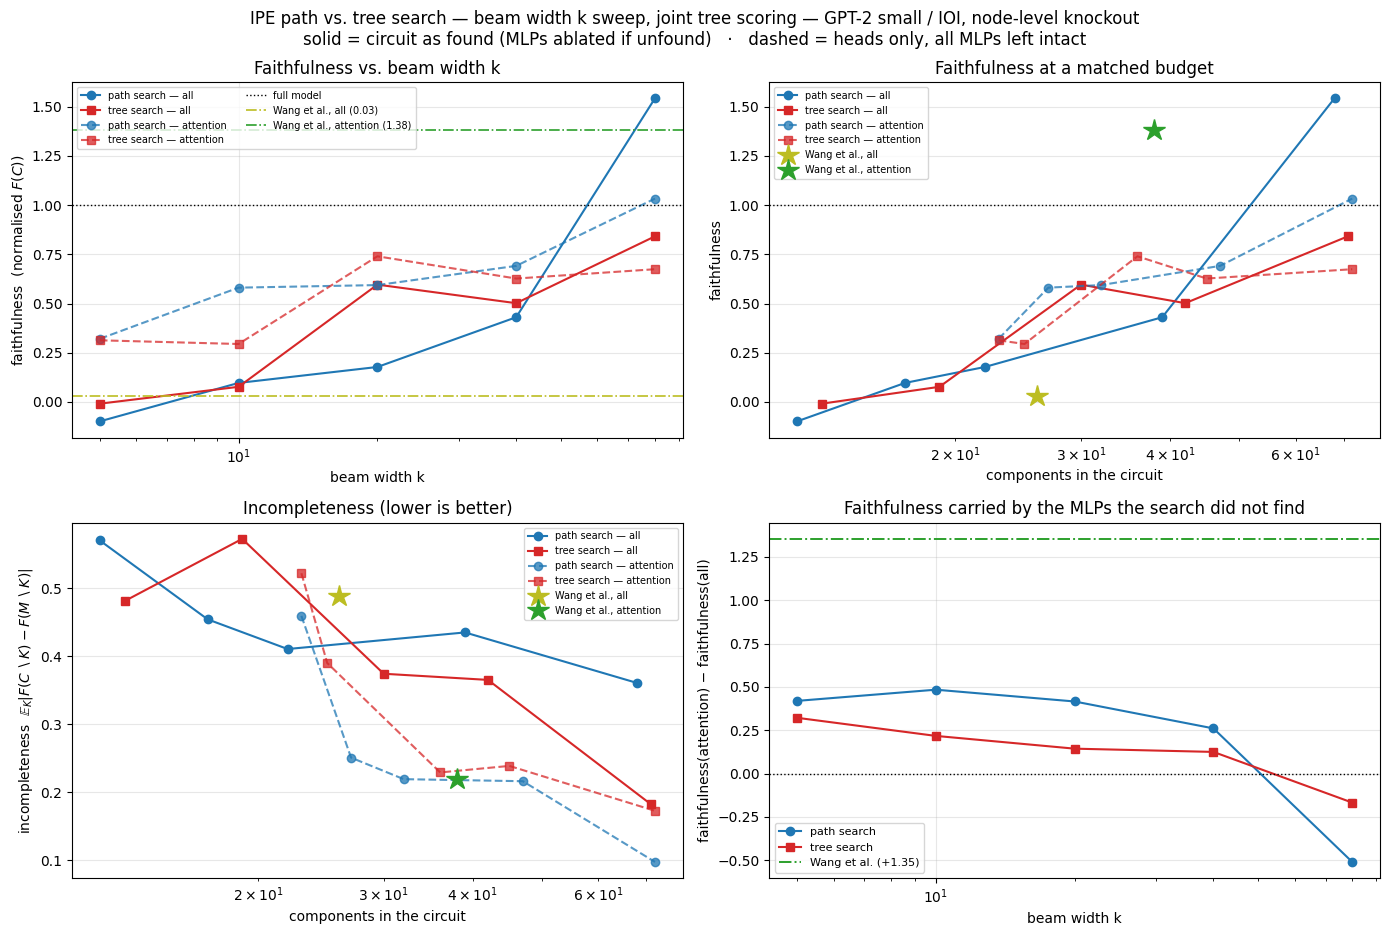

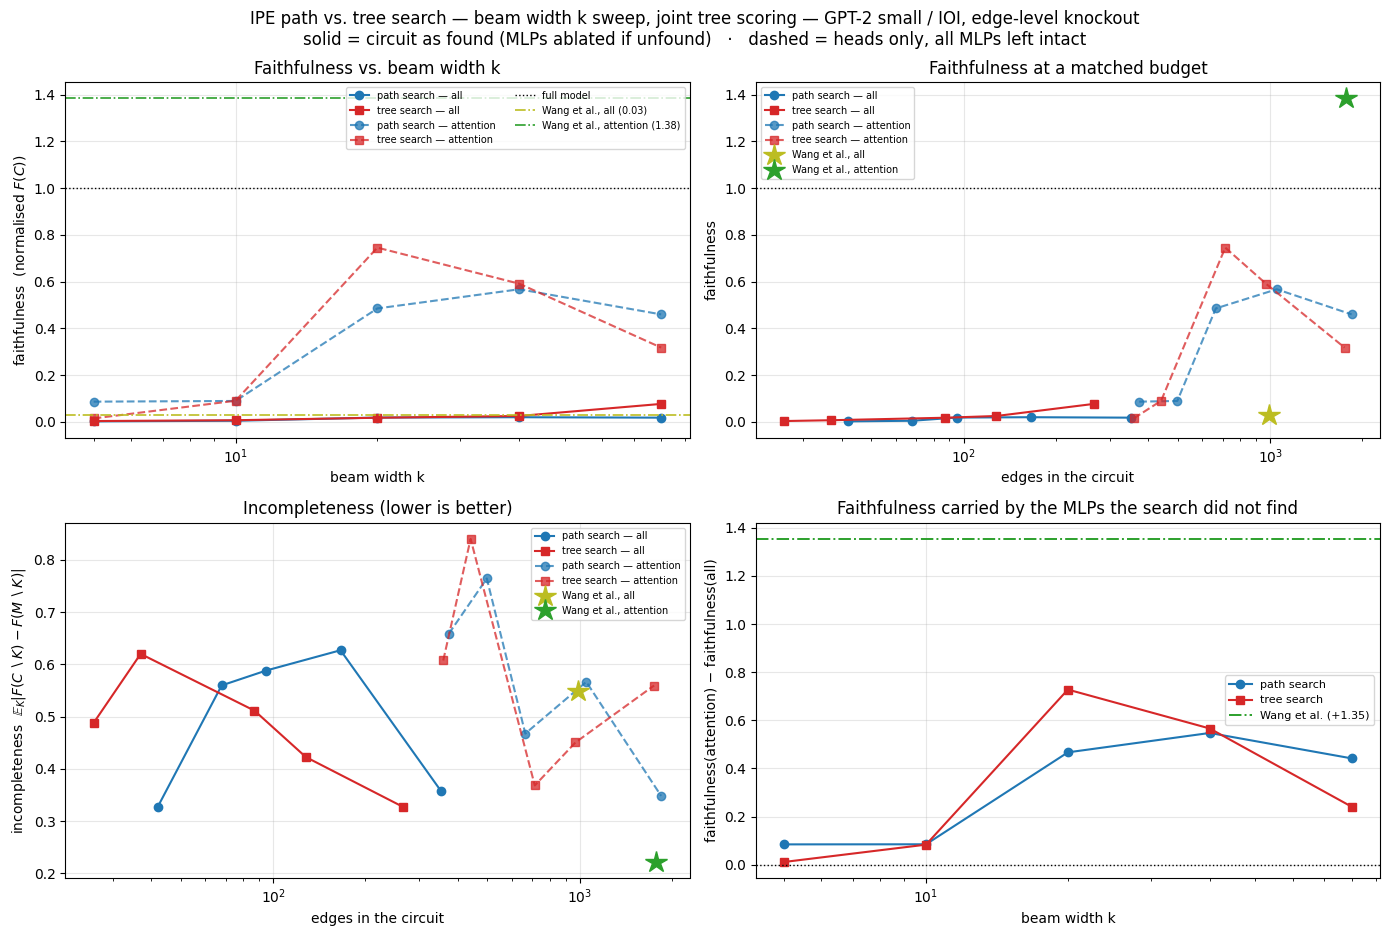

In [35]:
# ============================================================================================
# Plots for the top-k (beam) sweep.  Self-contained: needs only `df_beam`, `GRANULARITIES`,
# `SCOPES`, `CFG`, `OUT_DIR` (+ pd, np, plt, os). Does not use `plot_granularity`,
# `sweep_rows`, `STYLE` or `SWEEP_LABEL`.
# ============================================================================================
BEAM_STYLE = {
    "path":   dict(color="tab:blue", marker="o", label="path search"),
    "tree":   dict(color="tab:red",  marker="s", label="tree search"),
    "random": dict(color="tab:gray", marker="x", label="random, size-matched"),
}
BEAM_SCOPE_STYLE = {"all": dict(ls="-", alpha=1.0), "attention": dict(ls="--", alpha=0.75)}


def _beam_size_col(granularity):
    return "n_components" if granularity == "node" else "n_edges"


def _beam_rows(df, granularity, method, scope):
    """One method's sweep, ascending, with empty circuits dropped (they cannot go on a log axis).
    Under the `attention` scope emptiness is judged on the heads: the 12 MLPs are always present."""
    size = "n_heads" if scope == "attention" else _beam_size_col(granularity)
    sub = df[(df.granularity == granularity) & (df.scope == scope)
             & (df.method == method) & (df[size] > 0)]
    return sub.sort_values("threshold")


def _beam_style(method, scope):
    st = dict(BEAM_STYLE[method])
    label = st.pop("label")
    st.update(BEAM_SCOPE_STYLE[scope])
    st["label"] = f"{label} — {scope}"
    return st


def plot_beam(df, granularity, x_label="beam width k", tag="topk", out_dir=None):
    out_dir = OUT_DIR if out_dir is None else out_dir
    size_col = _beam_size_col(granularity)
    size_label = "components in the circuit" if granularity == "node" else "edges in the circuit"
    scoring = "joint" if CFG.tree_joint_scoring else "isolated"

    def ref(scope, column="faithfulness"):
        r = df[(df.granularity == granularity) & (df.scope == scope)
               & (df.method == "ground truth")]
        return r.iloc[0][column] if len(r) else np.nan

    fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
    fig.suptitle(f"IPE path vs. tree search — {x_label} sweep, {scoring} tree scoring — "
                 f"GPT-2 small / IOI, {granularity}-level knockout\n"
                 f"solid = circuit as found (MLPs ablated if unfound)   ·   "
                 f"dashed = heads only, all MLPs left intact", fontsize=12)

    # 1 -- faithfulness against the swept budget
    ax = axes[0, 0]
    for scope in SCOPES:
        for method in ("path", "tree"):
            sub = _beam_rows(df, granularity, method, scope)
            if len(sub):
                ax.plot(sub.threshold, sub.faithfulness, **_beam_style(method, scope))
    ax.axhline(1.0, color="black", lw=1, ls=":", label="full model")
    for scope, colour in (("all", "tab:olive"), ("attention", "tab:green")):
        g = ref(scope)
        if not np.isnan(g):
            ax.axhline(g, color=colour, lw=1.2, ls="-.", label=f"Wang et al., {scope} ({g:.2f})")
    ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel("faithfulness  (normalised $F(C)$)")
    ax.set_title(f"Faithfulness vs. {x_label}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)

    # 2 -- faithfulness against circuit size (the Pareto view)
    ax = axes[0, 1]
    for scope in SCOPES:
        for method in ("path", "tree"):
            sub = _beam_rows(df, granularity, method, scope)
            if len(sub):
                ax.plot(sub[size_col], sub.faithfulness, **_beam_style(method, scope))
    ax.axhline(1.0, color="black", lw=1, ls=":")
    for scope, colour in (("all", "tab:olive"), ("attention", "tab:green")):
        r = df[(df.granularity == granularity) & (df.scope == scope)
               & (df.method == "ground truth")]
        if len(r):
            ax.plot([r.iloc[0][size_col]], [r.iloc[0].faithfulness], marker="*", ms=16,
                    color=colour, ls="none", label=f"Wang et al., {scope}")
    ax.set_xscale("log")
    ax.set_xlabel(size_label)
    ax.set_ylabel("faithfulness")
    ax.set_title("Faithfulness at a matched budget")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

    # 3 -- incompleteness
    ax = axes[1, 0]
    for scope in SCOPES:
        for method in ("path", "tree"):
            sub = _beam_rows(df, granularity, method, scope)
            if len(sub):
                ax.plot(sub[size_col], sub.incompleteness_mean, **_beam_style(method, scope))
    for scope, colour in (("all", "tab:olive"), ("attention", "tab:green")):
        r = df[(df.granularity == granularity) & (df.scope == scope)
               & (df.method == "ground truth")]
        if len(r):
            ax.plot([r.iloc[0][size_col]], [r.iloc[0].incompleteness_mean], marker="*", ms=16,
                    color=colour, ls="none", label=f"Wang et al., {scope}")
    ax.set_xscale("log")
    ax.set_xlabel(size_label)
    ax.set_ylabel(r"incompleteness  $\mathbb{E}_K |F(C\setminus K) - F(M\setminus K)|$")
    ax.set_title("Incompleteness (lower is better)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

    # 4 -- what the MLPs the search missed are worth
    ax = axes[1, 1]
    for method in ("path", "tree"):
        a = _beam_rows(df, granularity, method, "all").set_index("threshold")
        b = _beam_rows(df, granularity, method, "attention").set_index("threshold")
        common = a.index.intersection(b.index)
        if len(common):
            ax.plot(common, b.loc[common].faithfulness - a.loc[common].faithfulness,
                    color=BEAM_STYLE[method]["color"], marker=BEAM_STYLE[method]["marker"],
                    label=f"{method} search")
    gap = ref("attention") - ref("all")
    if not np.isnan(gap):
        ax.axhline(gap, color="tab:green", lw=1.4, ls="-.", label=f"Wang et al. ({gap:+.2f})")
    ax.axhline(0.0, color="black", lw=1, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel("faithfulness(attention) − faithfulness(all)")
    ax.set_title("Faithfulness carried by the MLPs the search did not find")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    fig.tight_layout()
    path = os.path.join(out_dir, f"tree_vs_path_{granularity}_{tag}.png")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved {path}")
    return fig


for _g in GRANULARITIES:
    plot_beam(df_beam, _g)
plt.show()